In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
from functools import reduce
from functools import partial
import sys
import os
# use google drive
data_path = "./.data/Re_2520.h5"
sys.path.append('/content/drive/MyDrive/Research/Winter 2025/FNO')
import h5py
import numpy as np
from timeit import default_timer
import operator


## Defining models

Here we define layers/definitions for our UNet models. Can easily be replaced with other models.

In [2]:
from models.UNet import U_net

with h5py.File('./.data/Re_1280.h5', 'r') as f:
    for key in f.keys():
        print(f"{key}: shape={f[key].shape}, dtype={f[key].dtype}")

u_x: shape=(477, 100, 89, 133), dtype=float64
u_y: shape=(477, 100, 89, 133), dtype=float64


## Defining data loaders

MatReader class just makes it easier to deal with loading the mat files.

In [3]:
class MatReader(object):
    def __init__(self, file_path, to_torch=True, to_cuda=False, to_float=True, testing=True):
        super(MatReader, self).__init__()

        self.to_torch = to_torch
        self.to_cuda = to_cuda
        self.to_float = to_float
        self.testing = testing

        self.file_path = file_path

        self.data = None
        self.old_mat = None
        self._load_file()

    def _load_file(self):
          self.data = h5py.File(self.file_path)
          self.old_mat = False

    def load_file(self, file_path):
        self.file_path = file_path
        self._load_file()

    def read_field(self, field):
        if not self.testing:
          x = self.data[field]
        else:
          x = self.data[field][:,:,:,:100]

        if not self.old_mat:
            x = x[()]
            x = np.transpose(x, axes=range(len(x.shape) - 1, -1, -1))

        if self.to_float:
            x = x.astype(np.float32)

        if self.to_torch:
            x = torch.from_numpy(x)

            if self.to_cuda:
                x = x.cuda()

        return x

    def set_cuda(self, to_cuda):
        self.to_cuda = to_cuda

    def set_torch(self, to_torch):
        self.to_torch = to_torch

    def set_float(self, to_float):
        self.to_float = to_float


Now we define a FluidDataset class to play nicely with torch.

In [4]:
class FluidDataset(torch.utils.data.Dataset):
  def __init__(self, u0_data, target_data):
    self.u0_data = u0_data
    self.target_data = target_data

  def __len__(self):
    return len(self.u0_data)

  def __getitem__(self, idx):
    return {'u0': self.u0_data[idx],
            'targets': self.target_data[idx]}

## Defining training variables

Here we do some housekeeping and define the expected geometry of our task. Specifically, we:
* Seed/set our torch device
* Set the total number of consecutive timesteps we expect per sequence
* Set the expected dimension of the data
* Set how many timesteps we want to use as input to our model
* Set how many timesteps we want to predict forward

In [5]:
# Some housekeeping
seed = 5496#20250913#11519#
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
np.random.seed(seed)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# How many timesteps are in the dataset (should usually remain hardcoded at 12, but we do have some longer data)
T_len = 12

# Dimensions of the PIV data
S1 = 133
S2 = 89

# How many timesteps to use as input for the prediction. Usually 1 or 2
T_in = 1

# How many timesteps to predict forward. Could be as many as T_len - T_in.
T_out = 10

Here we set the network/training parameters. Note that we have a "testing" mode which will allow us to train/test things faster when trying to debug, ect.

In [ ]:

testing = False

if testing:
    ntrain = 32
    ntest = 32
    epochs = 10
else:
    # Number of sequences to use in the training set
    ntrain = 429
    # Number of sequences to use in the testing set
    ntest = 48
    # Number of epochs to train for
    epochs = 200

# Setting the batch size:
batch_size = 16

# Setting speed parameter
speed = "5Hz_200fps"

In [7]:
def count_params(model):
    c = 0
    for p in list(model.parameters()):
        c += reduce(operator.mul,
                    list(p.size()+(2,) if p.is_complex() else p.size()))
    return c


## Loading data



Here we actually load our data using MatReader

In [8]:
# File where the data is. Note that we usually use the 't12_dt5_clean.mat' files.
fname = data_path

reader = MatReader(fname, testing=testing)

Actually read in and arrange the data

In [9]:
# X and Y components of velocity are stored separately
u_x = reader.read_field('u_x')
u_y = reader.read_field('u_y')

u_x = u_x.permute(3, 0, 1, 2)
u_y = u_y.permute(3, 0, 1, 2)

p = np.random.permutation(len(u_x))
u_x = u_x[p]
u_y = u_y[p]

u_x_mean = u_x[:ntrain, ...].mean()
u_x_std = u_x[:ntrain, ...].std()
u_y_mean = u_y[:ntrain, ...].mean()
u_y_std = u_y[:ntrain, ...].std()

u_x = (u_x - u_x_mean) / u_x_std
u_y = (u_y - u_y_mean) / u_y_std

# Model inputs for training
train_a_x = u_x[:ntrain, :, :, :T_in]
train_a_y = u_y[:ntrain, :, :, :T_in]
train_a = torch.stack((train_a_x, train_a_y), -1)
train_a = torch.flatten(train_a, -2)  # This will need to change if i move to 2 input steps again
train_a = torch.permute(train_a, (0, 3, 1, 2))

# Model inputs for testing
test_a_x = u_x[-ntest:, :, :, :T_in]
test_a_y = u_y[-ntest:, :, :, :T_in]
test_a = torch.stack((test_a_x, test_a_y), -1)
test_a = torch.flatten(test_a, -2) # This will need to change if i move to 2 input steps again
test_a = torch.permute(test_a, (0, 3, 1, 2))

# Target velocities for training
train_u_x = u_x[:ntrain, :, :, T_in:T_out + T_in]
train_u_y = u_y[:ntrain, :, :, T_in:T_out + T_in]
train_u = torch.stack((train_u_x, train_u_y), -1)
# train_u = torch.flatten(train_u, -2) # Changed
train_u = torch.permute(train_u, (0, 3, 4, 1, 2))

# Target velocities for testing
test_u_x = u_x[-ntest:,:,:,T_in:T_out + T_in]
test_u_y = u_y[-ntest:,:,:,T_in:T_out + T_in]
test_u = torch.stack((test_u_x, test_u_y), -1)
# test_u = torch.flatten(test_u, -2) # Changed
test_u = torch.permute(test_u, (0, 3, 4, 1, 2))

print("train_u_x:", train_u_x.shape)
print("stacked:", torch.stack((train_u_x, train_u_y), -1).shape)
print("train_u:", train_u.shape)

# Make sure things are the size we expect
assert (S2 == train_u.shape[-1])
assert (S1 == train_u.shape[-2])

# Build our training and testing datasets
train_dataset = FluidDataset(train_a, train_u)
test_dataset = FluidDataset(test_a, test_u)

# Build torch dataloaders from our datasets
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True, num_workers=4, pin_memory=True)#, persistent_workers=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False) # Don't shuffle the test_loader

train_u_x: torch.Size([429, 133, 89, 10])
stacked: torch.Size([429, 133, 89, 10, 2])
train_u: torch.Size([429, 10, 2, 133, 89])


In [10]:
u_x.shape

torch.Size([490, 133, 89, 100])

## Defining training functions

Now we define functions that we will use for training

In [11]:
#loss function with rel/abs Lp loss
class LpLoss(object):
    def __init__(self, d=2, p=2, size_average=True, reduction=True):
        super(LpLoss, self).__init__()

        #Dimension and Lp-norm type are postive
        assert d > 0 and p > 0

        self.d = d
        self.p = p
        self.reduction = reduction
        self.size_average = size_average

    def abs(self, x, y):
        num_examples = x.size()[0]

        #Assume uniform mesh
        h = 1.0 / (x.size()[1] - 1.0)
        all_norms = (h**(self.d/self.p))*torch.norm(x.view(num_examples,-1) - y.view(num_examples,-1), self.p, 1)

        if self.reduction:
            if self.size_average:
                return torch.mean(all_norms)
            else:
                return torch.sum(all_norms)

        return all_norms

    def rel(self, x, y):
        num_examples = x.size()[0]

        diff_norms = torch.norm(x.reshape(num_examples,-1) - y.reshape(num_examples,-1), self.p, 1)
        y_norms = torch.norm(y.reshape(num_examples,-1), self.p, 1)

        if self.reduction:
            if self.size_average:
                return torch.mean(diff_norms/y_norms)
            else:
                return torch.sum(diff_norms/y_norms)
        return diff_norms/y_norms

    def __call__(self, x, y):
        return self.rel(x, y)


In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
from timeit import default_timer
import matplotlib.pyplot as plt
import math
import numpy as np

# PITA Loss settings
from models.PITA import PITALoss

# adv-NO settings
from models.adv_NO import AdvNOLoss, EMA, spectrum_error

def train_recursive(
      model,
      train_dataloader,
      test_dataloader,
      num_steps=10,
      num_epochs=200,
      lr=1e-3,
      weight_decay=1e-4,
      warmup_epochs=5,
      clip_grad=0.5,
      plot_interval=10,
      device="cuda",
      teacher_forcing=False,
      early_stopping_patience=30,
      u_x_std=1.0,
      u_y_std=1.0,
      use_pita=True,
      PITA_threshold=0.05,
      PITA_downsample=4,
      PITA_alpha_l0=1e-4,
      use_adv=False,
      adv_warmup_epochs=20,
      adv_beta=0.1,
      adv_use_perceptual=True,
      adv_max_frames=64,
      adv_lr_D=1e-4,
      adv_ema_decay=0.999,
      ):

    assert not (use_pita and use_adv), "use_pita and use_adv can't both be on"

    model = model.to(device)

    # integrate PITA
    if use_pita:
        pita_loss = PITALoss(dx=1.0, dy=1.0, dt=1.0, threshold=PITA_threshold, 
                               downsample=PITA_downsample, alpha_l0=PITA_alpha_l0).to(device)
        # fixed target coefficients from the whole training set
        pita_loss.precompute_true_coefficients(train_dataloader)
        print("Discovered physics from training data:")
        pita_loss.print_discovered_equations()
        trainable_params = list(model.parameters()) + list(pita_loss.parameters())
    else:
        pita_loss = trainable_params = list(model.parameters())

    # integrate adv-NO, discriminator gets its own optimizer
    if use_adv:
        adv_loss = AdvNOLoss(input_channels=2, beta_adv=adv_beta,
                             use_perceptual=adv_use_perceptual,
                             max_disc_frames=adv_max_frames).to(device)
        optimizer_D = optim.Adam(adv_loss.D.parameters(), lr=adv_lr_D)
        ema_G = EMA(model, adv_ema_decay)
        ema_G.register()
        ema_D = EMA(adv_loss.D, adv_ema_decay)
        ema_D.register()
        if teacher_forcing:
            print("WARNING: teacher forcing disabled for adv-NO")
            teacher_forcing = False

    optimizer = optim.AdamW(trainable_params, lr=lr, weight_decay=weight_decay) # trainable params now include PITA if using PITA loss
    criterion = nn.MSELoss()

    if teacher_forcing:
        print("WARNING: Teacher forcing enabled.")

    # # cosine annealing with warmup
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return (epoch + 1) / warmup_epochs
        progress = (epoch - warmup_epochs) / max(1, (num_epochs - warmup_epochs))
        return 0.5 * (1 + math.cos(math.pi * progress))  # cosine from 1 -> 0
    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)

    train_losses, test_losses = [], []
    train_losses_scaled, test_losses_scaled = [], []

    best_val_loss = float("inf")
    best_state_dict = None
    patience_counter = 0

    for epoch in range(num_epochs):
        t1 = default_timer()
        epoch_loss = 0.0
        epoch_loss_scaled = 0.0

        # teacher forcing schedule (decays linearly)
        tf_ratio = 1.0 - 0.5 * (epoch / num_epochs) if teacher_forcing else 0.0

        # adv-NO: L1 only during warmup, then adversarial + perceptual
        if use_adv:
            adv_loss.adversarial_enabled = epoch >= adv_warmup_epochs
            if epoch == adv_warmup_epochs:
                print(f"adv-NO stage 2: enabling RaGAN + perceptual losses at epoch {epoch+1}")

        for batch in train_dataloader:
            u0 = batch['u0'].to(device, non_blocking=True)
            targets = batch['targets'].to(device, non_blocking=True)

            optimizer.zero_grad()
            predictions = [u0]
            u_current = u0

            # recursive rollout with optional teacher forcing
            for t in range(num_steps):
                u_next = model(u_current)
                predictions.append(u_next)

                if torch.rand(1).item() < tf_ratio:
                    u_current = targets[:, t]  # ground truth
                else:
                    u_current = u_next

            # loss over all horizons
            pred_seq = torch.stack(predictions[1:], dim=1)
            target_seq = targets

            # separated based on PITA
            if use_pita:
                loss, parts = pita_loss(pred_seq, target_seq)
                
                if epoch == 0 or (epoch + 1) % 10 == 0:
                    print(f"  L_data={parts['L_data'].item():.3e} "
                          f"L_phy={parts['L_phy'].item():.3e} "
                          f"L_con={parts['L_con'].item():.3e} "
                          f"sigma_d={pita_loss.log_sigma_data.item():.2f} "
                          f"sigma_p={pita_loss.log_sigma_phy.item():.2f} "
                          f"sigma_c={pita_loss.log_sigma_con.item():.2f}")


                loss_x = F.mse_loss(pred_seq[:, :, 0], target_seq[:, :, 0]) * u_x_std**2
                loss_y = F.mse_loss(pred_seq[:, :, 1], target_seq[:, :, 1]) * u_y_std**2
            elif use_adv:
                loss, parts = adv_loss(pred_seq, target_seq)

                if epoch == 0 or (epoch + 1) % 10 == 0:
                    print(f"  L_pixel={parts['L_pixel'].item():.3e} "
                          f"L_percep={parts['L_percep'].item():.3e} "
                          f"L_adv={parts['L_adv'].item():.3e}")

                with torch.no_grad():
                    loss_x = F.mse_loss(pred_seq[:, :, 0], target_seq[:, :, 0]) * u_x_std**2
                    loss_y = F.mse_loss(pred_seq[:, :, 1], target_seq[:, :, 1]) * u_y_std**2
            else:
                loss = 0.0
                loss_x = 0.0
                loss_y = 0.0
                for t in range(1, len(predictions)):
                    loss += criterion(predictions[t], targets[:, t-1])
                    loss_x += criterion(predictions[t][:, 0], targets[:, t-1][:, 0])
                    loss_y += criterion(predictions[t][:, 1], targets[:, t-1][:, 1])
                loss = loss / num_steps
                loss_x = loss_x * u_x_std**2
                loss_y = loss_y * u_y_std**2
            # The factor of 2 makes the loss actually match original units
            loss_scaled = (loss_x + loss_y) / (2 *num_steps)

            

            loss.backward()

            # Print gradients
            # total_norm = torch.norm(torch.stack([p.grad.detach().norm(2) for p in model.parameters() if p.grad is not None]), 2)
            # print(f"Grad norm: {total_norm.item():.3f}")

            if clip_grad is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), clip_grad)
            optimizer.step()

            # adv-NO: discriminator step, then EMA update
            if use_adv:
                if adv_loss.adversarial_enabled:
                    optimizer_D.zero_grad()
                    loss_D = adv_loss.discriminator_loss(pred_seq.detach(), target_seq)
                    loss_D.backward()
                    optimizer_D.step()
                    ema_D.update()
                ema_G.update()

            epoch_loss += loss.item()
            epoch_loss_scaled += loss_scaled.item()

        avg_train_loss = epoch_loss / len(train_dataloader)
        avg_train_loss_scaled = epoch_loss_scaled / len(train_dataloader)

        train_losses.append(avg_train_loss)
        train_losses_scaled.append(avg_train_loss_scaled)

        # validation (adv-NO uses the EMA weights)
        model.eval()
        if use_adv:
            ema_G.apply_shadow()
        epoch_test_loss = 0.0
        epoch_test_loss_scaled = 0.0
        epoch_spec_err = 0.0
        with torch.no_grad():
            for batch in test_dataloader:
                u0 = batch['u0'].to(device)
                targets = batch['targets'].to(device)
                predictions = recursive_prediction(model, u0, num_steps=num_steps, device=device)
                loss = 0.0
                loss_x = 0.0
                loss_y = 0.0
                for t in range(1, len(predictions)):
                    loss += criterion(predictions[t], targets[:, t-1])
                    loss_x += criterion(predictions[t][:, 0], targets[:, t-1][:, 0])
                    loss_y += criterion(predictions[t][:, 1], targets[:, t-1][:, 1])
                loss = loss / num_steps
                loss_x = loss_x * u_x_std**2
                loss_y = loss_y * u_y_std**2
                loss_scaled = (loss_x + loss_y) / (2 * num_steps)
                epoch_test_loss += loss.item()
                epoch_test_loss_scaled += loss_scaled.item()
                if use_adv:
                    val_pred_seq = torch.stack(predictions[1:], dim=1)
                    epoch_spec_err += spectrum_error(val_pred_seq, targets)
        model.train()
        avg_test_loss = epoch_test_loss / len(test_dataloader)
        avg_test_loss_scaled = epoch_test_loss_scaled / len(test_dataloader)
        avg_spec_err = epoch_spec_err / len(test_dataloader) if use_adv else None
        test_losses.append(avg_test_loss)
        test_losses_scaled.append(avg_test_loss_scaled)

        model.train()
        scheduler.step()

        t2 = default_timer()
        spec_str = f"SpecErr: {avg_spec_err:.4e}, " if use_adv else ""
        print(f"Epoch {epoch+1}/{num_epochs}, "
              f"Train Loss: {avg_train_loss_scaled:.8f}, "
              f"Test Loss: {avg_test_loss_scaled:.8f}, "
              + spec_str +
              f"Time: {t2 - t1:.2f}s, "
              f"LR: {scheduler.get_last_lr()[0]:.2e}")

        if use_pita and (epoch == 0 or (epoch + 1) % plot_interval == 0):
            # PDE discovered from the last training batch's rollout vs the fixed truth
            pita_loss.print_discovered_equations(pred_seq.detach())

        # early stopping (adv-NO selects on spectrum error instead of MSE)
        selection_metric = avg_spec_err if use_adv else avg_test_loss
        if selection_metric < 0.99 * best_val_loss:  # small tolerance
            best_val_loss = selection_metric
            best_state_dict = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= early_stopping_patience:
                if use_adv:
                    ema_G.restore()
                print(f"Early stopping at epoch {epoch+1}. Best val metric: {best_val_loss:.8f}")
                break
        if use_adv:
            ema_G.restore()

        if (epoch+1) % plot_interval == 0:
            # plot_velocity_field(predictions)
            plt.plot(train_losses_scaled, label="training")
            plt.plot(test_losses_scaled, label="testing")
            plt.yscale('log') # Added log scale to y-axis
            plt.xlabel('Epoch')
            plt.ylabel('Loss')
            plt.title('Training/Validation Loss')
            plt.legend()
            plt.show()


    # restore best weights
    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)

    # Plot
    plt.plot(train_losses, label="training")
    plt.plot(test_losses, label="testing")
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training/Validation Loss')
    plt.legend()
    plt.show()

    return train_losses, test_losses, best_val_loss


def recursive_prediction(model, u0, num_steps=10, device="cuda"):
    # model.eval()
    predictions = [u0]
    u_current = u0
    with torch.no_grad():
        for t in range(num_steps):
            u_next = model(u_current.to(device))
            predictions.append(u_next)
            u_current = u_next
    # model.train()
    return predictions


# Plotting utility
def plot_velocity_field(preds):
    """
    Plots the 2D velocity field (u, v) for all timesteps in the predictions.

    Args:
        preds: A list of tensors, where each tensor represents the predicted
               velocity field at a particular timestep. The shape of each tensor
               should be (batch_size, 2, height, width).
    """
    num_timesteps = len(preds)

    for t in range(num_timesteps):
        # Get the prediction for the current timestep
        pred_t = preds[t]

        # Assuming batch_size = 1, get u and v components
        u = pred_t[0, 0].cpu().detach().numpy()  # x-component
        v = pred_t[0, 1].cpu().detach().numpy()  # y-component

        H, W = u.shape
        X, Y = np.meshgrid(np.linspace(0, 1, W), np.linspace(0, 1, H))

        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        # Plot u (horizontal velocity)
        im0 = axes[0].imshow(u, origin="lower", extent=[0, 1, 0, 1], cmap="RdBu")
        axes[0].set_title(f"u-component (horizontal), t={t}")
        fig.colorbar(im0, ax=axes[0])

        # Plot v (vertical velocity)
        im1 = axes[1].imshow(v, origin="lower", extent=[0, 1, 0, 1], cmap="RdBu")
        axes[1].set_title(f"v-component (vertical), t={t}")
        fig.colorbar(im1, ax=axes[1])

        # Plot vector field (quiver)
        step = 5  # downsample for visualization
        axes[2].quiver(X[::step, ::step], Y[::step, ::step], u[::step, ::step], v[::step, ::step])
        axes[2].set_title(f"Velocity Field (quiver), t={t}")
        axes[2].set_xlim(0, 1)
        axes[2].set_ylim(0, 1)

        plt.tight_layout()
        plt.show()

In [13]:
# # PITA test
# from models.UNet import U_net
# from models.PITA import PITALoss

# _smoke_model = U_net(input_channels=2, output_channels=2,
#                      kernel_size=5, dropout_rate=0.2).to(device)
# _smoke_pita  = PITALoss(dx=1.0, dy=1.0, dt=1.0,
#                         threshold=0.05, downsample=4, alpha_l0=1e-4).to(device)
# _smoke_opt   = torch.optim.AdamW(
#     list(_smoke_model.parameters()) + list(_smoke_pita.parameters()), lr=1e-3,
# )

# _batch = next(iter(train_loader))
# _u0 = _batch['u0'].to(device)
# _targets = _batch['targets'].to(device)

# _preds = [_u0]; _cur = _u0
# for _t in range(T_out):
#     _nxt = _smoke_model(_cur); _preds.append(_nxt); _cur = _nxt
# _pred_seq = torch.stack(_preds[1:], dim=1)

# _total, _parts = _smoke_pita(_pred_seq, _targets)
# print(f"pred_seq shape: {tuple(_pred_seq.shape)}")
# for k, v in _parts.items():
#     print(f"  {k}: {v.item():.4e}")
# print(f"  total:  {_total.item():.4e}")
# _total.backward(); _smoke_opt.step()
# print("Backward + step succeeded.")

# del _smoke_model, _smoke_pita, _smoke_opt, _batch
# del _u0, _targets, _preds, _cur, _nxt, _pred_seq, _total, _parts

In [14]:
# _san_model = U_net(input_channels=2, output_channels=2,
#                    kernel_size=5, dropout_rate=0.2).to(device)
# _san_train_losses, _san_test_losses, _ = train_recursive(
#     _san_model, train_loader, test_loader,
#     num_steps=T_out, num_epochs=5,
#     plot_interval=5, teacher_forcing=False,
#     clip_grad=0.5, early_stopping_patience=999,
#     u_x_std=u_x_std, u_y_std=u_y_std,
#     use_pita=True, PITA_threshold=0.05, PITA_downsample=4, PITA_alpha_l0=1e-4,
# )
# assert _san_train_losses[-1] < _san_train_losses[0], "loss did not decrease"
# print("Sanity training run succeeded.")
# del _san_model, _san_train_losses, _san_test_losses

## Training

Now we're ready to train!

In [15]:
# # Define the model and put it on the GPU (or other device).
# # Can also change model parameters (e.g., input_channels, output_channels, etc.)
# model = U_net(input_channels=2, output_channels=2, kernel_size=5, dropout_rate=0.2).to(device)

# # Train the model using recursive prediction
# print(f"Total number of parameters: {count_params(model)}")
# # tags
# tags = "FINAL_2"

# epochs = 200
# train_losses, test_losses, best_val_losses = train_recursive(model
#                                                              , train_loader
#                                                              , test_loader
#                                                              , num_steps=T_out
#                                                              , num_epochs=epochs
#                                                              , plot_interval=10
#                                                              , teacher_forcing=False
#                                                              , clip_grad=0.5
#                                                              , early_stopping_patience=30
#                                                              , u_x_std=u_x_std
#                                                              , u_y_std=u_y_std)


In [16]:
import os
from datetime import date

Baseline params: 58109814
Epoch 1/200, Train Loss: 0.00142474, Test Loss: 0.00078851, Time: 13.91s, LR: 4.00e-04
Epoch 2/200, Train Loss: 0.00054382, Test Loss: 0.00041514, Time: 12.93s, LR: 6.00e-04
Epoch 3/200, Train Loss: 0.00036123, Test Loss: 0.00033108, Time: 12.85s, LR: 8.00e-04
Epoch 4/200, Train Loss: 0.00030765, Test Loss: 0.00029167, Time: 13.26s, LR: 1.00e-03
Epoch 5/200, Train Loss: 0.00028577, Test Loss: 0.00038260, Time: 12.90s, LR: 1.00e-03
Epoch 6/200, Train Loss: 0.00027715, Test Loss: 0.00027264, Time: 12.68s, LR: 1.00e-03
Epoch 7/200, Train Loss: 0.00025774, Test Loss: 0.00024958, Time: 12.44s, LR: 1.00e-03
Epoch 8/200, Train Loss: 0.00025733, Test Loss: 0.00024785, Time: 12.38s, LR: 9.99e-04
Epoch 9/200, Train Loss: 0.00023357, Test Loss: 0.00023716, Time: 12.47s, LR: 9.99e-04
Epoch 10/200, Train Loss: 0.00023210, Test Loss: 0.00023961, Time: 12.92s, LR: 9.98e-04


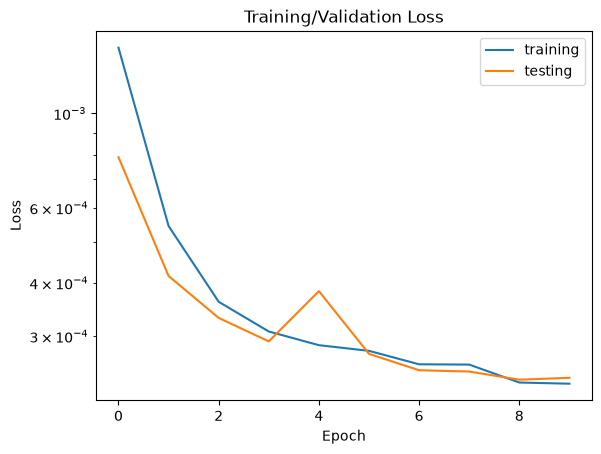

Epoch 11/200, Train Loss: 0.00022644, Test Loss: 0.00022084, Time: 14.33s, LR: 9.98e-04
Epoch 12/200, Train Loss: 0.00022600, Test Loss: 0.00022616, Time: 13.50s, LR: 9.97e-04
Epoch 13/200, Train Loss: 0.00021579, Test Loss: 0.00022357, Time: 13.60s, LR: 9.96e-04
Epoch 14/200, Train Loss: 0.00021181, Test Loss: 0.00022840, Time: 14.06s, LR: 9.95e-04
Epoch 15/200, Train Loss: 0.00020889, Test Loss: 0.00021977, Time: 13.81s, LR: 9.94e-04
Epoch 16/200, Train Loss: 0.00020826, Test Loss: 0.00021921, Time: 12.95s, LR: 9.92e-04
Epoch 17/200, Train Loss: 0.00020402, Test Loss: 0.00021451, Time: 13.63s, LR: 9.91e-04
Epoch 18/200, Train Loss: 0.00020153, Test Loss: 0.00020799, Time: 14.34s, LR: 9.89e-04
Epoch 19/200, Train Loss: 0.00019577, Test Loss: 0.00021405, Time: 13.68s, LR: 9.87e-04
Epoch 20/200, Train Loss: 0.00019865, Test Loss: 0.00021104, Time: 13.48s, LR: 9.85e-04


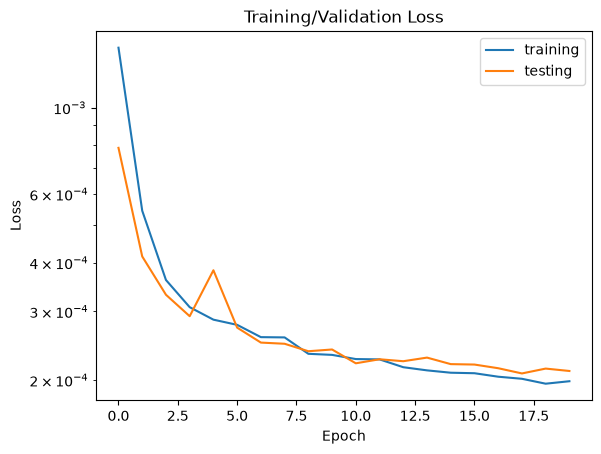

Epoch 21/200, Train Loss: 0.00019049, Test Loss: 0.00021327, Time: 13.13s, LR: 9.83e-04
Epoch 22/200, Train Loss: 0.00018906, Test Loss: 0.00020297, Time: 13.17s, LR: 9.81e-04
Epoch 23/200, Train Loss: 0.00018674, Test Loss: 0.00021135, Time: 13.23s, LR: 9.79e-04
Epoch 24/200, Train Loss: 0.00018750, Test Loss: 0.00020811, Time: 13.09s, LR: 9.77e-04
Epoch 25/200, Train Loss: 0.00018051, Test Loss: 0.00020844, Time: 13.14s, LR: 9.74e-04
Epoch 26/200, Train Loss: 0.00017920, Test Loss: 0.00020497, Time: 13.10s, LR: 9.72e-04
Epoch 27/200, Train Loss: 0.00017746, Test Loss: 0.00020715, Time: 13.21s, LR: 9.69e-04
Epoch 28/200, Train Loss: 0.00017449, Test Loss: 0.00020695, Time: 13.08s, LR: 9.66e-04
Epoch 29/200, Train Loss: 0.00016903, Test Loss: 0.00021867, Time: 13.15s, LR: 9.63e-04
Epoch 30/200, Train Loss: 0.00016569, Test Loss: 0.00020488, Time: 13.17s, LR: 9.60e-04


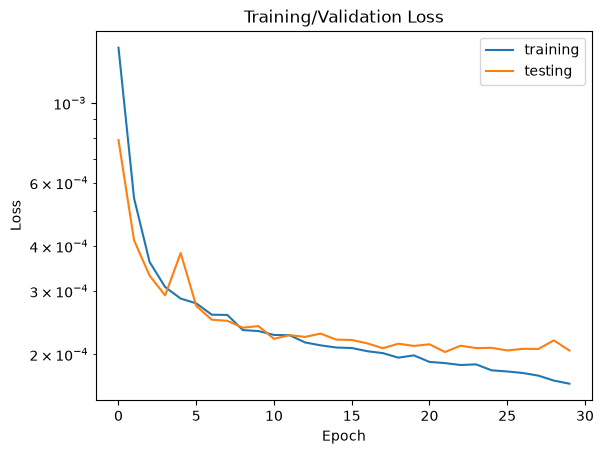

Epoch 31/200, Train Loss: 0.00016867, Test Loss: 0.00022484, Time: 13.14s, LR: 9.57e-04
Epoch 32/200, Train Loss: 0.00016685, Test Loss: 0.00020503, Time: 13.23s, LR: 9.53e-04
Epoch 33/200, Train Loss: 0.00015913, Test Loss: 0.00020975, Time: 13.22s, LR: 9.50e-04
Epoch 34/200, Train Loss: 0.00015365, Test Loss: 0.00020665, Time: 13.18s, LR: 9.46e-04
Epoch 35/200, Train Loss: 0.00015263, Test Loss: 0.00020816, Time: 13.19s, LR: 9.43e-04
Epoch 36/200, Train Loss: 0.00015661, Test Loss: 0.00021859, Time: 13.19s, LR: 9.39e-04
Epoch 37/200, Train Loss: 0.00014858, Test Loss: 0.00020727, Time: 13.23s, LR: 9.35e-04
Epoch 38/200, Train Loss: 0.00014580, Test Loss: 0.00020964, Time: 13.15s, LR: 9.31e-04
Epoch 39/200, Train Loss: 0.00014269, Test Loss: 0.00020648, Time: 13.29s, LR: 9.27e-04
Epoch 40/200, Train Loss: 0.00013985, Test Loss: 0.00020453, Time: 13.22s, LR: 9.23e-04


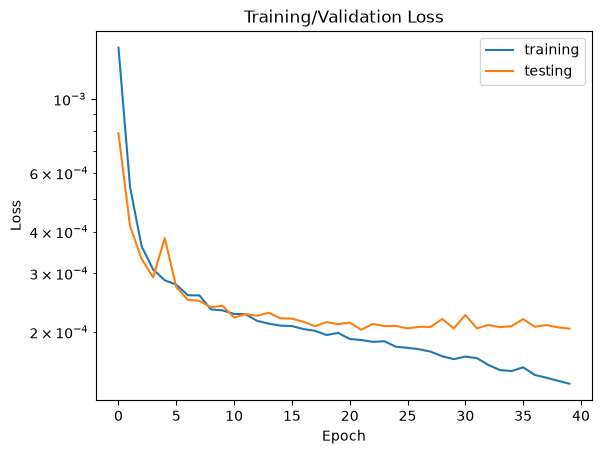

Epoch 41/200, Train Loss: 0.00014157, Test Loss: 0.00021454, Time: 13.24s, LR: 9.18e-04
Epoch 42/200, Train Loss: 0.00013812, Test Loss: 0.00020792, Time: 13.32s, LR: 9.14e-04
Epoch 43/200, Train Loss: 0.00013505, Test Loss: 0.00020357, Time: 13.26s, LR: 9.09e-04
Epoch 44/200, Train Loss: 0.00013494, Test Loss: 0.00020441, Time: 13.21s, LR: 9.05e-04
Epoch 45/200, Train Loss: 0.00013231, Test Loss: 0.00020736, Time: 13.31s, LR: 9.00e-04
Epoch 46/200, Train Loss: 0.00013348, Test Loss: 0.00020554, Time: 13.27s, LR: 8.95e-04
Epoch 47/200, Train Loss: 0.00013312, Test Loss: 0.00020682, Time: 13.32s, LR: 8.90e-04
Epoch 48/200, Train Loss: 0.00013178, Test Loss: 0.00021052, Time: 13.28s, LR: 8.85e-04
Epoch 49/200, Train Loss: 0.00012782, Test Loss: 0.00020689, Time: 13.33s, LR: 8.80e-04
Epoch 50/200, Train Loss: 0.00012473, Test Loss: 0.00020659, Time: 13.20s, LR: 8.74e-04


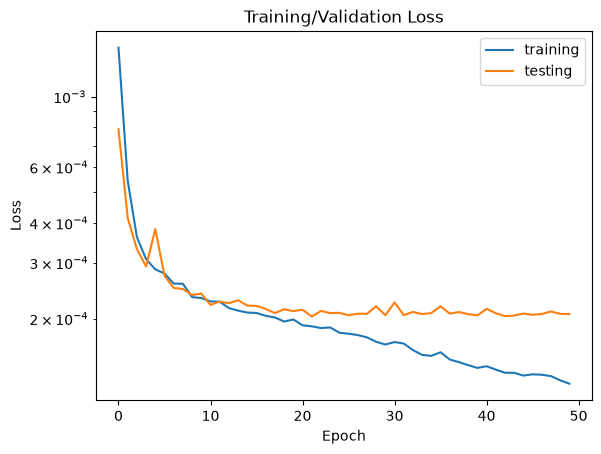

Epoch 51/200, Train Loss: 0.00012545, Test Loss: 0.00020743, Time: 14.06s, LR: 8.69e-04
Epoch 52/200, Train Loss: 0.00012333, Test Loss: 0.00021689, Time: 14.23s, LR: 8.63e-04
Early stopping at epoch 52. Best val metric: 0.09761351


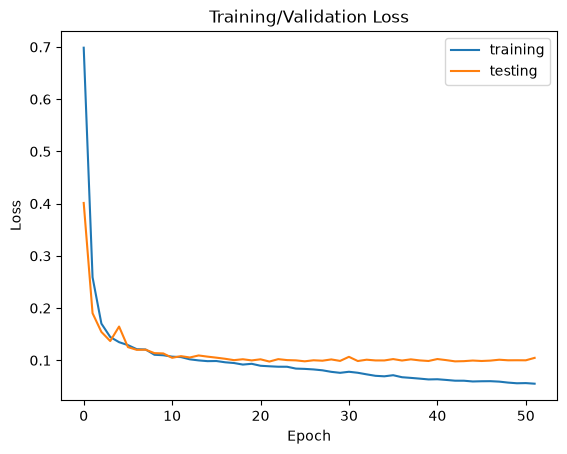

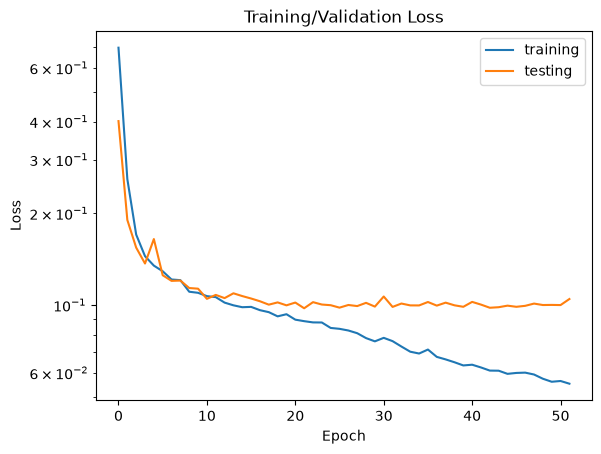

In [17]:
# === Base Model ===
baseline_tags = "BASELINE_NO_PITA"
# baseline_epochs = 200

model_base = U_net(input_channels=2, output_channels=2, kernel_size=5, dropout_rate=0.2,).to(device)

print(f"Baseline params: {count_params(model_base)}")
b_train_losses, b_test_losses, b_best = train_recursive(model_base
                                                        , train_loader
                                                        , test_loader
                                                        , num_steps=T_out
                                                        , num_epochs=epochs
                                                        , plot_interval=10
                                                        , teacher_forcing=False
                                                        , clip_grad=0.5
                                                        , early_stopping_patience=30
                                                        , u_x_std=u_x_std
                                                        , u_y_std=u_y_std
                                                        , use_pita=False)

plt.plot(b_train_losses, label="training")
plt.plot(b_test_losses, label="testing")
plt.yscale('log') # Added log scale to y-axis
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training/Validation Loss')
plt.legend()
plt.show()

PITA params: 58109814
Discovered physics from training data:
  ground truth: u_t = -1.048*u_y +0.163*v_x -0.1076*u*u_y -0.06354*v*u_x +0.0601*u*v_x -0.04889*v*v_y
                v_t = -1.536*v_y -0.1102*u*v_y -0.0739*v*v_x
  L_data=1.003e+00 L_phy=1.999e-02 L_con=5.948e-01 sigma_d=0.00 sigma_p=0.00 sigma_c=0.00
  L_data=1.007e+00 L_phy=1.915e-02 L_con=1.602e-01 sigma_d=0.00 sigma_p=-0.00 sigma_c=-0.00
  L_data=9.998e-01 L_phy=1.809e-02 L_con=1.602e-01 sigma_d=0.00 sigma_p=-0.00 sigma_c=-0.00
  L_data=9.868e-01 L_phy=1.755e-02 L_con=1.610e-01 sigma_d=0.00 sigma_p=-0.00 sigma_c=-0.00
  L_data=9.695e-01 L_phy=1.710e-02 L_con=4.245e-01 sigma_d=0.00 sigma_p=-0.00 sigma_c=-0.00
  L_data=9.618e-01 L_phy=1.664e-02 L_con=1.607e-01 sigma_d=0.00 sigma_p=-0.00 sigma_c=-0.00
  L_data=9.478e-01 L_phy=1.633e-02 L_con=1.618e-01 sigma_d=0.00 sigma_p=-0.00 sigma_c=-0.00
  L_data=9.290e-01 L_phy=1.554e-02 L_con=1.106e-01 sigma_d=0.00 sigma_p=-0.00 sigma_c=-0.00
  L_data=9.159e-01 L_phy=1.491e-02 L_con=9

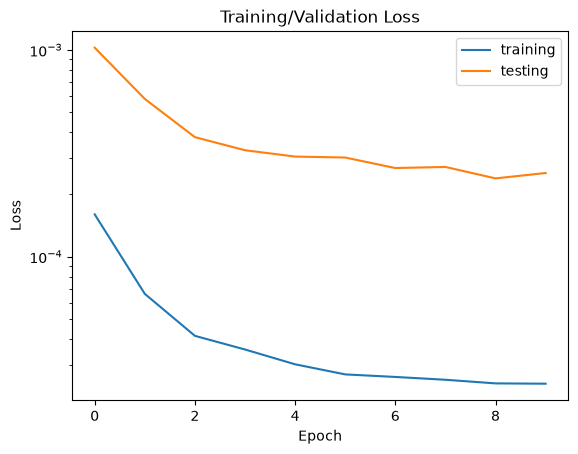

Epoch 11/200, Train Loss: 0.00002319, Test Loss: 0.00024975, Time: 14.29s, LR: 9.98e-04
Epoch 12/200, Train Loss: 0.00002269, Test Loss: 0.00023717, Time: 13.64s, LR: 9.97e-04
Epoch 13/200, Train Loss: 0.00002185, Test Loss: 0.00022657, Time: 13.56s, LR: 9.96e-04
Epoch 14/200, Train Loss: 0.00002158, Test Loss: 0.00023996, Time: 13.69s, LR: 9.95e-04
Epoch 15/200, Train Loss: 0.00002319, Test Loss: 0.00024231, Time: 13.86s, LR: 9.94e-04
Epoch 16/200, Train Loss: 0.00002144, Test Loss: 0.00021639, Time: 13.75s, LR: 9.92e-04
Epoch 17/200, Train Loss: 0.00002100, Test Loss: 0.00021809, Time: 13.74s, LR: 9.91e-04
Epoch 18/200, Train Loss: 0.00002095, Test Loss: 0.00024223, Time: 13.70s, LR: 9.89e-04
Epoch 19/200, Train Loss: 0.00002117, Test Loss: 0.00021956, Time: 13.74s, LR: 9.87e-04
  L_data=3.074e-01 L_phy=6.175e-03 L_con=3.237e-03 sigma_d=-0.42 sigma_p=-0.44 sigma_c=-0.45
  L_data=2.865e-01 L_phy=5.937e-03 L_con=2.348e-03 sigma_d=-0.42 sigma_p=-0.44 sigma_c=-0.45
  L_data=3.063e-01 L_p

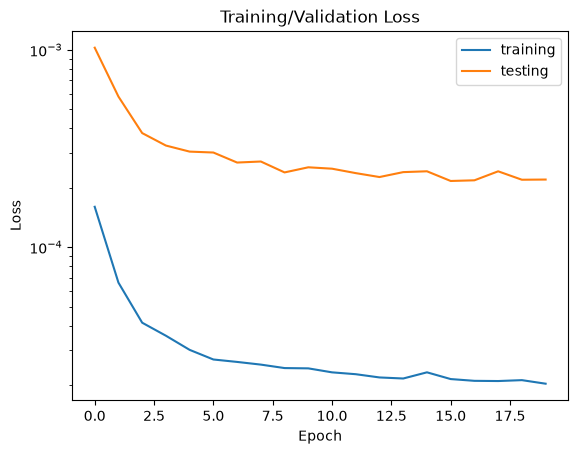

Epoch 21/200, Train Loss: 0.00001990, Test Loss: 0.00020661, Time: 13.79s, LR: 9.83e-04
Epoch 22/200, Train Loss: 0.00001977, Test Loss: 0.00020978, Time: 13.79s, LR: 9.81e-04
Epoch 23/200, Train Loss: 0.00002040, Test Loss: 0.00021833, Time: 13.62s, LR: 9.79e-04
Epoch 24/200, Train Loss: 0.00001943, Test Loss: 0.00022043, Time: 13.77s, LR: 9.77e-04
Epoch 25/200, Train Loss: 0.00002009, Test Loss: 0.00022212, Time: 13.67s, LR: 9.74e-04
Epoch 26/200, Train Loss: 0.00001916, Test Loss: 0.00020841, Time: 13.60s, LR: 9.72e-04
Epoch 27/200, Train Loss: 0.00001854, Test Loss: 0.00020715, Time: 13.66s, LR: 9.69e-04
Epoch 28/200, Train Loss: 0.00001833, Test Loss: 0.00020529, Time: 13.79s, LR: 9.66e-04
Epoch 29/200, Train Loss: 0.00001803, Test Loss: 0.00020704, Time: 13.68s, LR: 9.63e-04
  L_data=2.936e-01 L_phy=6.213e-03 L_con=2.509e-03 sigma_d=-0.55 sigma_p=-0.69 sigma_c=-0.70
  L_data=2.783e-01 L_phy=5.636e-03 L_con=2.472e-03 sigma_d=-0.55 sigma_p=-0.69 sigma_c=-0.70
  L_data=2.786e-01 L_p

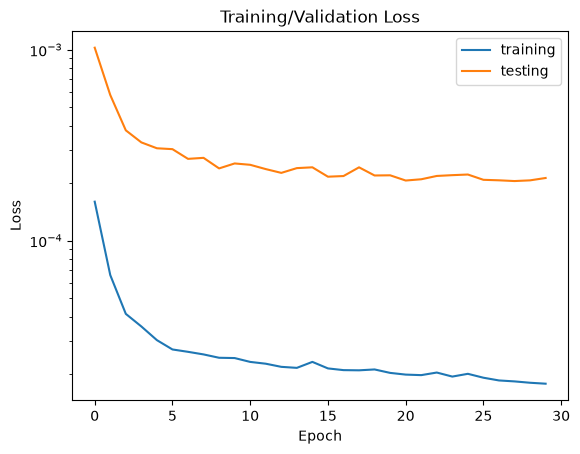

Epoch 31/200, Train Loss: 0.00001719, Test Loss: 0.00020391, Time: 13.61s, LR: 9.57e-04
Epoch 32/200, Train Loss: 0.00001751, Test Loss: 0.00020657, Time: 13.63s, LR: 9.53e-04
Epoch 33/200, Train Loss: 0.00001848, Test Loss: 0.00021568, Time: 14.05s, LR: 9.50e-04
Epoch 34/200, Train Loss: 0.00001731, Test Loss: 0.00020638, Time: 14.20s, LR: 9.46e-04
Epoch 35/200, Train Loss: 0.00001631, Test Loss: 0.00020636, Time: 13.62s, LR: 9.43e-04
Epoch 36/200, Train Loss: 0.00001638, Test Loss: 0.00021716, Time: 13.68s, LR: 9.39e-04
Epoch 37/200, Train Loss: 0.00001595, Test Loss: 0.00020794, Time: 14.00s, LR: 9.35e-04
Epoch 38/200, Train Loss: 0.00001629, Test Loss: 0.00021081, Time: 14.25s, LR: 9.31e-04
Epoch 39/200, Train Loss: 0.00001576, Test Loss: 0.00020564, Time: 13.94s, LR: 9.27e-04
  L_data=2.677e-01 L_phy=5.308e-03 L_con=2.633e-03 sigma_d=-0.62 sigma_p=-0.94 sigma_c=-0.95
  L_data=2.594e-01 L_phy=5.455e-03 L_con=2.539e-03 sigma_d=-0.62 sigma_p=-0.94 sigma_c=-0.95
  L_data=2.628e-01 L_p

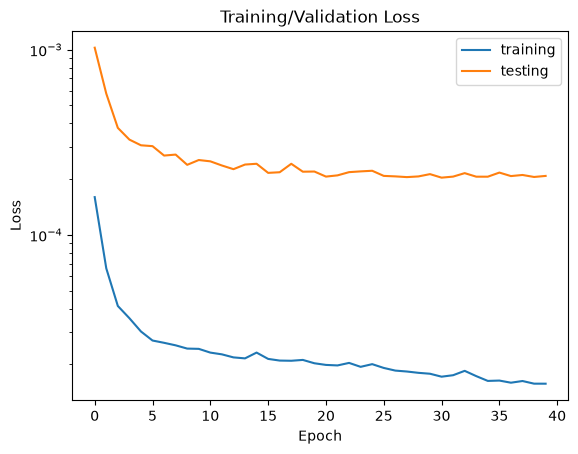

Epoch 41/200, Train Loss: 0.00001606, Test Loss: 0.00021537, Time: 13.78s, LR: 9.18e-04
Epoch 42/200, Train Loss: 0.00001513, Test Loss: 0.00020586, Time: 13.98s, LR: 9.14e-04
Epoch 43/200, Train Loss: 0.00001468, Test Loss: 0.00020908, Time: 13.87s, LR: 9.09e-04
Epoch 44/200, Train Loss: 0.00001447, Test Loss: 0.00021946, Time: 14.22s, LR: 9.05e-04
Epoch 45/200, Train Loss: 0.00001454, Test Loss: 0.00020585, Time: 14.17s, LR: 9.00e-04
Epoch 46/200, Train Loss: 0.00001441, Test Loss: 0.00020882, Time: 14.02s, LR: 8.95e-04
Epoch 47/200, Train Loss: 0.00001421, Test Loss: 0.00020972, Time: 13.89s, LR: 8.90e-04
Epoch 48/200, Train Loss: 0.00001405, Test Loss: 0.00020531, Time: 13.96s, LR: 8.85e-04
Epoch 49/200, Train Loss: 0.00001433, Test Loss: 0.00022600, Time: 14.05s, LR: 8.80e-04
  L_data=2.671e-01 L_phy=4.766e-03 L_con=2.848e-03 sigma_d=-0.67 sigma_p=-1.17 sigma_c=-1.18
  L_data=2.550e-01 L_phy=4.743e-03 L_con=2.339e-03 sigma_d=-0.67 sigma_p=-1.17 sigma_c=-1.18
  L_data=2.601e-01 L_p

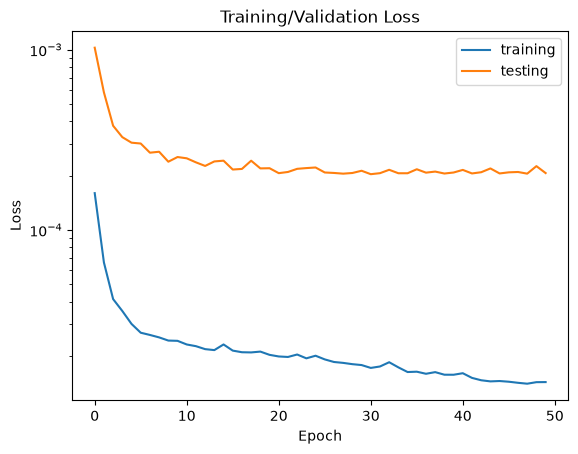

Epoch 51/200, Train Loss: 0.00001371, Test Loss: 0.00021048, Time: 14.02s, LR: 8.69e-04
Early stopping at epoch 51. Best val metric: 0.09923661


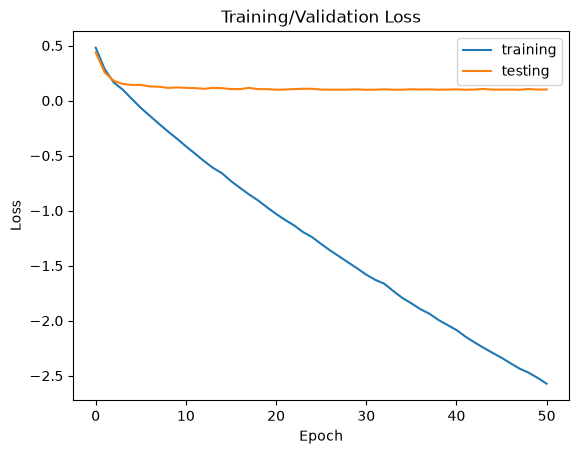

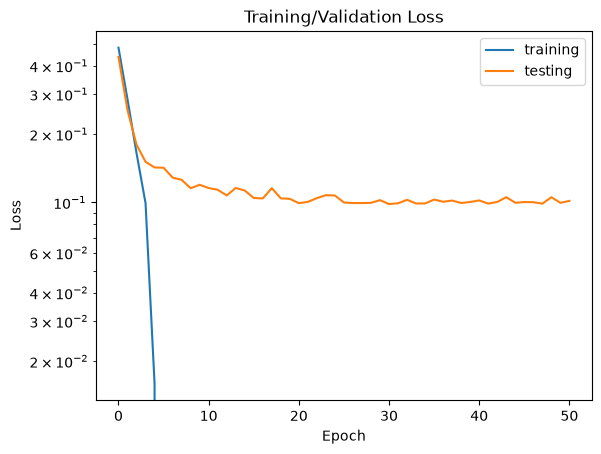

In [18]:
# === With Pita ===
pita_tags = "BASELINE_WITH_PITA"

model_pita = U_net(
    input_channels=2, output_channels=2,
    kernel_size=5, dropout_rate=0.2,
).to(device)

print(f"PITA params: {count_params(model_pita)}")
p_train_losses, p_test_losses, p_best = train_recursive(
    model_pita,
    train_loader,
    test_loader,
    num_steps=T_out,
    num_epochs=epochs,
    plot_interval=10,
    teacher_forcing=False,
    clip_grad=0.5,
    early_stopping_patience=30,
    u_x_std=u_x_std,
    u_y_std=u_y_std,
    use_pita=True,
    PITA_threshold=0.01,
    PITA_downsample=4,
    PITA_alpha_l0=1e-4,
)

plt.plot(p_train_losses, label="training")
plt.plot(p_test_losses, label="testing")
plt.yscale('log') # Added log scale to y-axis
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training/Validation Loss')
plt.legend()
plt.show()

adv-NO generator params: 58109814
  L_pixel=6.318e-01 L_percep=0.000e+00 L_adv=0.000e+00
  L_pixel=6.176e-01 L_percep=0.000e+00 L_adv=0.000e+00
  L_pixel=6.037e-01 L_percep=0.000e+00 L_adv=0.000e+00
  L_pixel=6.199e-01 L_percep=0.000e+00 L_adv=0.000e+00
  L_pixel=5.769e-01 L_percep=0.000e+00 L_adv=0.000e+00
  L_pixel=5.772e-01 L_percep=0.000e+00 L_adv=0.000e+00
  L_pixel=5.687e-01 L_percep=0.000e+00 L_adv=0.000e+00
  L_pixel=5.548e-01 L_percep=0.000e+00 L_adv=0.000e+00
  L_pixel=5.486e-01 L_percep=0.000e+00 L_adv=0.000e+00
  L_pixel=5.152e-01 L_percep=0.000e+00 L_adv=0.000e+00
  L_pixel=4.923e-01 L_percep=0.000e+00 L_adv=0.000e+00
  L_pixel=4.954e-01 L_percep=0.000e+00 L_adv=0.000e+00
  L_pixel=4.996e-01 L_percep=0.000e+00 L_adv=0.000e+00
  L_pixel=4.723e-01 L_percep=0.000e+00 L_adv=0.000e+00
  L_pixel=5.053e-01 L_percep=0.000e+00 L_adv=0.000e+00
  L_pixel=4.512e-01 L_percep=0.000e+00 L_adv=0.000e+00
  L_pixel=4.677e-01 L_percep=0.000e+00 L_adv=0.000e+00
  L_pixel=4.345e-01 L_percep=0.

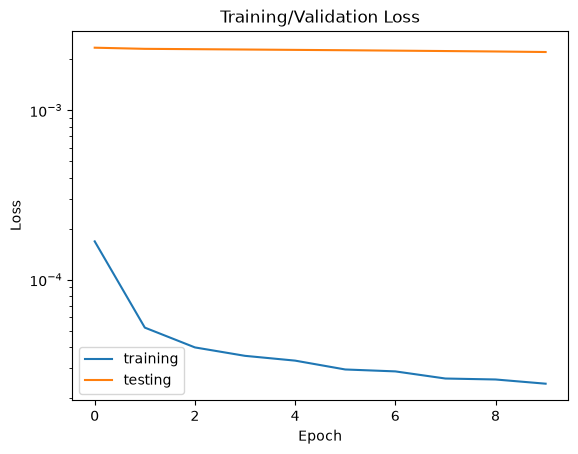

Epoch 11/200, Train Loss: 0.00002383, Test Loss: 0.00219172, SpecErr: 6.0723e+01, Time: 15.11s, LR: 9.98e-04
Epoch 12/200, Train Loss: 0.00002403, Test Loss: 0.00217654, SpecErr: 5.9755e+01, Time: 15.55s, LR: 9.97e-04
Epoch 13/200, Train Loss: 0.00002324, Test Loss: 0.00216073, SpecErr: 5.8216e+01, Time: 14.44s, LR: 9.96e-04
Epoch 14/200, Train Loss: 0.00002232, Test Loss: 0.00214466, SpecErr: 5.7190e+01, Time: 14.44s, LR: 9.95e-04
Epoch 15/200, Train Loss: 0.00002183, Test Loss: 0.00212951, SpecErr: 5.6555e+01, Time: 14.21s, LR: 9.94e-04
Epoch 16/200, Train Loss: 0.00002209, Test Loss: 0.00211207, SpecErr: 5.4478e+01, Time: 14.03s, LR: 9.92e-04
Epoch 17/200, Train Loss: 0.00002108, Test Loss: 0.00209251, SpecErr: 5.2870e+01, Time: 14.19s, LR: 9.91e-04
Epoch 18/200, Train Loss: 0.00002108, Test Loss: 0.00207461, SpecErr: 5.2059e+01, Time: 14.01s, LR: 9.89e-04
Epoch 19/200, Train Loss: 0.00002044, Test Loss: 0.00205676, SpecErr: 5.0956e+01, Time: 14.37s, LR: 9.87e-04
  L_pixel=1.558e-01

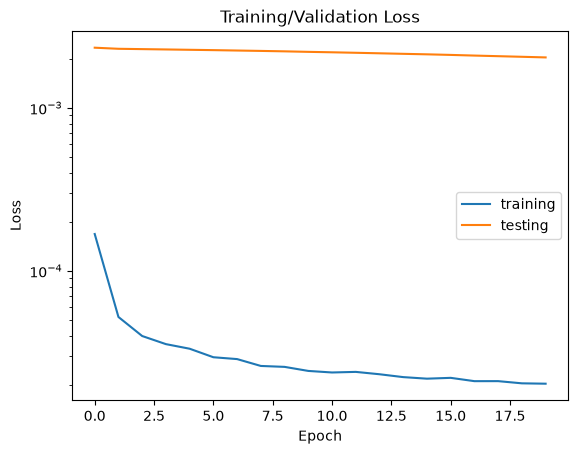

adv-NO stage 2: enabling RaGAN + perceptual losses at epoch 21
[adv-NO] 972 MiB VRAM free entering stage 2; reducing max_disc_frames 16 -> 5 (~93 MiB per frame)
[adv-NO] WARNING: only 5 critic frames per step. The RaGAN population mean gets noisy below ~8, weakening adversarial training. Prefer lowering batch_size (the rollout graph dominates memory) over running this thin.
Epoch 21/200, Train Loss: 0.00002914, Test Loss: 0.00202199, SpecErr: 5.0311e+01, Time: 18.27s, LR: 9.83e-04
Epoch 22/200, Train Loss: 0.00003037, Test Loss: 0.00201631, SpecErr: 5.0777e+01, Time: 18.02s, LR: 9.81e-04
Epoch 23/200, Train Loss: 0.00003210, Test Loss: 0.00198282, SpecErr: 4.6968e+01, Time: 17.98s, LR: 9.79e-04
Epoch 24/200, Train Loss: 0.00003044, Test Loss: 0.00196171, SpecErr: 4.6582e+01, Time: 17.99s, LR: 9.77e-04
Epoch 25/200, Train Loss: 0.00002920, Test Loss: 0.00194079, SpecErr: 4.3993e+01, Time: 18.91s, LR: 9.74e-04
Epoch 26/200, Train Loss: 0.00002893, Test Loss: 0.00192679, SpecErr: 4.3256e+

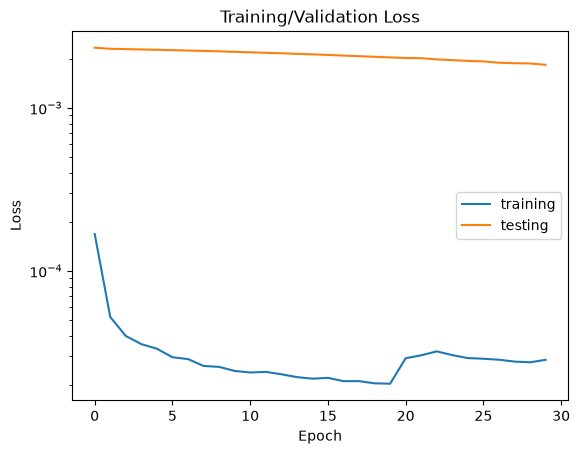

Epoch 31/200, Train Loss: 0.00002751, Test Loss: 0.00181353, SpecErr: 3.6485e+01, Time: 16.91s, LR: 9.57e-04
Epoch 32/200, Train Loss: 0.00002888, Test Loss: 0.00177935, SpecErr: 3.4550e+01, Time: 18.40s, LR: 9.53e-04
Epoch 33/200, Train Loss: 0.00002832, Test Loss: 0.00176898, SpecErr: 3.3866e+01, Time: 18.98s, LR: 9.50e-04
Epoch 34/200, Train Loss: 0.00003140, Test Loss: 0.00176699, SpecErr: 3.3623e+01, Time: 19.20s, LR: 9.46e-04
Epoch 35/200, Train Loss: 0.00003309, Test Loss: 0.00171892, SpecErr: 3.1210e+01, Time: 19.38s, LR: 9.43e-04
Epoch 36/200, Train Loss: 0.00002743, Test Loss: 0.00171452, SpecErr: 3.0940e+01, Time: 19.23s, LR: 9.39e-04
Epoch 37/200, Train Loss: 0.00002756, Test Loss: 0.00167528, SpecErr: 2.8747e+01, Time: 19.19s, LR: 9.35e-04
Epoch 38/200, Train Loss: 0.00002661, Test Loss: 0.00165425, SpecErr: 2.7796e+01, Time: 19.36s, LR: 9.31e-04
Epoch 39/200, Train Loss: 0.00002637, Test Loss: 0.00164135, SpecErr: 2.6519e+01, Time: 19.50s, LR: 9.27e-04
  L_pixel=1.885e-01

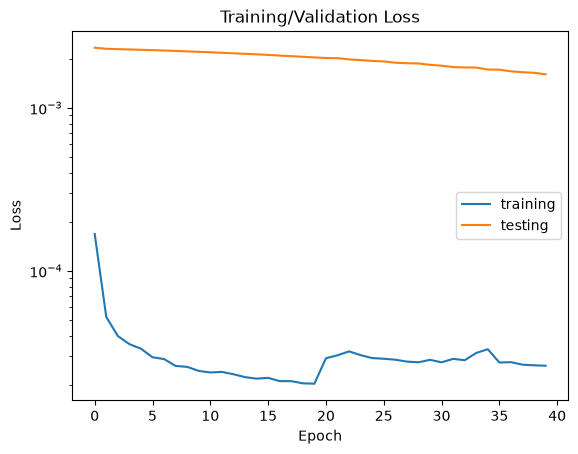

Epoch 41/200, Train Loss: 0.00002572, Test Loss: 0.00159534, SpecErr: 2.4637e+01, Time: 19.11s, LR: 9.18e-04
Epoch 42/200, Train Loss: 0.00002598, Test Loss: 0.00157264, SpecErr: 2.3696e+01, Time: 18.43s, LR: 9.14e-04
Epoch 43/200, Train Loss: 0.00002727, Test Loss: 0.00155155, SpecErr: 2.2433e+01, Time: 18.51s, LR: 9.09e-04
Epoch 44/200, Train Loss: 0.00002681, Test Loss: 0.00153393, SpecErr: 2.2164e+01, Time: 18.20s, LR: 9.05e-04
Epoch 45/200, Train Loss: 0.00002664, Test Loss: 0.00151575, SpecErr: 2.1325e+01, Time: 18.83s, LR: 9.00e-04
Epoch 46/200, Train Loss: 0.00002613, Test Loss: 0.00147650, SpecErr: 1.9361e+01, Time: 18.15s, LR: 8.95e-04
Epoch 47/200, Train Loss: 0.00002754, Test Loss: 0.00148745, SpecErr: 1.9664e+01, Time: 18.29s, LR: 8.90e-04
Epoch 48/200, Train Loss: 0.00003293, Test Loss: 0.00142719, SpecErr: 1.8421e+01, Time: 18.30s, LR: 8.85e-04
Epoch 49/200, Train Loss: 0.00002726, Test Loss: 0.00141950, SpecErr: 1.7690e+01, Time: 18.25s, LR: 8.80e-04
  L_pixel=1.904e-01

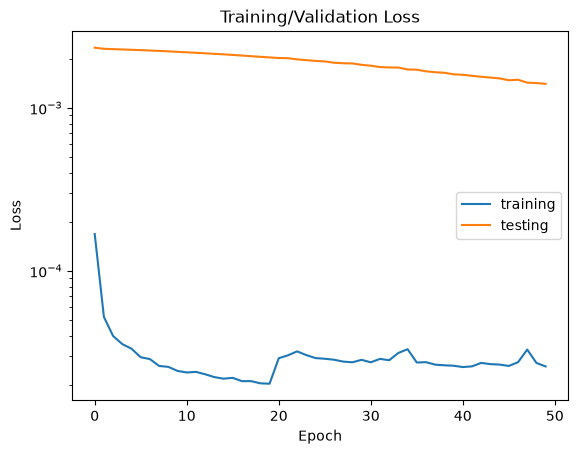

Epoch 51/200, Train Loss: 0.00002545, Test Loss: 0.00135280, SpecErr: 1.5342e+01, Time: 18.93s, LR: 8.69e-04
Epoch 52/200, Train Loss: 0.00002563, Test Loss: 0.00134521, SpecErr: 1.4928e+01, Time: 19.14s, LR: 8.63e-04
Epoch 53/200, Train Loss: 0.00002621, Test Loss: 0.00133690, SpecErr: 1.4697e+01, Time: 19.23s, LR: 8.58e-04
Epoch 54/200, Train Loss: 0.00002553, Test Loss: 0.00130801, SpecErr: 1.3885e+01, Time: 19.25s, LR: 8.52e-04
Epoch 55/200, Train Loss: 0.00002653, Test Loss: 0.00129016, SpecErr: 1.3448e+01, Time: 19.65s, LR: 8.46e-04
Epoch 56/200, Train Loss: 0.00002987, Test Loss: 0.00125866, SpecErr: 1.2495e+01, Time: 19.59s, LR: 8.41e-04
Epoch 57/200, Train Loss: 0.00002815, Test Loss: 0.00124777, SpecErr: 1.2286e+01, Time: 18.35s, LR: 8.35e-04
Epoch 58/200, Train Loss: 0.00002576, Test Loss: 0.00124142, SpecErr: 1.2872e+01, Time: 18.22s, LR: 8.29e-04
Epoch 59/200, Train Loss: 0.00002623, Test Loss: 0.00120755, SpecErr: 1.2017e+01, Time: 18.18s, LR: 8.22e-04
  L_pixel=1.863e-01

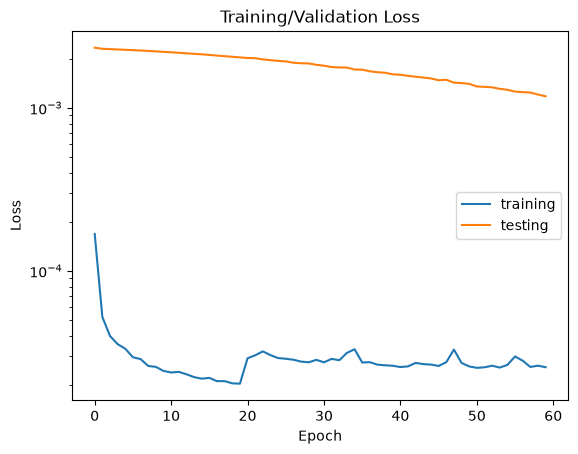

Epoch 61/200, Train Loss: 0.00002507, Test Loss: 0.00114273, SpecErr: 1.0203e+01, Time: 18.09s, LR: 8.10e-04
Epoch 62/200, Train Loss: 0.00002500, Test Loss: 0.00112665, SpecErr: 1.0148e+01, Time: 18.06s, LR: 8.04e-04
Epoch 63/200, Train Loss: 0.00002518, Test Loss: 0.00110865, SpecErr: 9.7692e+00, Time: 18.18s, LR: 7.97e-04
Epoch 64/200, Train Loss: 0.00002533, Test Loss: 0.00107914, SpecErr: 9.3513e+00, Time: 18.19s, LR: 7.91e-04
Epoch 65/200, Train Loss: 0.00002574, Test Loss: 0.00107599, SpecErr: 9.5463e+00, Time: 18.46s, LR: 7.84e-04
Epoch 66/200, Train Loss: 0.00002568, Test Loss: 0.00104515, SpecErr: 8.5474e+00, Time: 18.13s, LR: 7.77e-04
Epoch 67/200, Train Loss: 0.00002798, Test Loss: 0.00104390, SpecErr: 8.6219e+00, Time: 18.25s, LR: 7.71e-04
Epoch 68/200, Train Loss: 0.00002928, Test Loss: 0.00100239, SpecErr: 8.0129e+00, Time: 18.64s, LR: 7.64e-04
Epoch 69/200, Train Loss: 0.00002703, Test Loss: 0.00098798, SpecErr: 7.5496e+00, Time: 19.19s, LR: 7.57e-04
  L_pixel=1.919e-01

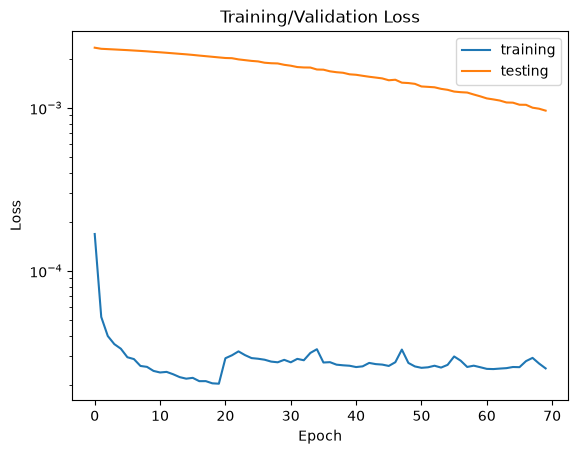

Epoch 71/200, Train Loss: 0.00002585, Test Loss: 0.00095391, SpecErr: 7.0271e+00, Time: 19.27s, LR: 7.43e-04
Epoch 72/200, Train Loss: 0.00002553, Test Loss: 0.00092275, SpecErr: 6.5375e+00, Time: 19.63s, LR: 7.36e-04
Epoch 73/200, Train Loss: 0.00002602, Test Loss: 0.00092058, SpecErr: 6.7160e+00, Time: 20.25s, LR: 7.29e-04
Epoch 74/200, Train Loss: 0.00002582, Test Loss: 0.00087611, SpecErr: 5.9231e+00, Time: 18.82s, LR: 7.22e-04
Epoch 75/200, Train Loss: 0.00002624, Test Loss: 0.00087135, SpecErr: 5.9780e+00, Time: 19.03s, LR: 7.14e-04
Epoch 76/200, Train Loss: 0.00002683, Test Loss: 0.00084185, SpecErr: 5.4299e+00, Time: 18.66s, LR: 7.07e-04
Epoch 77/200, Train Loss: 0.00002590, Test Loss: 0.00084090, SpecErr: 5.6158e+00, Time: 18.49s, LR: 7.00e-04
Epoch 78/200, Train Loss: 0.00002715, Test Loss: 0.00083335, SpecErr: 5.7305e+00, Time: 18.53s, LR: 6.92e-04
Epoch 79/200, Train Loss: 0.00002590, Test Loss: 0.00080527, SpecErr: 5.4214e+00, Time: 18.39s, LR: 6.85e-04
  L_pixel=1.831e-01

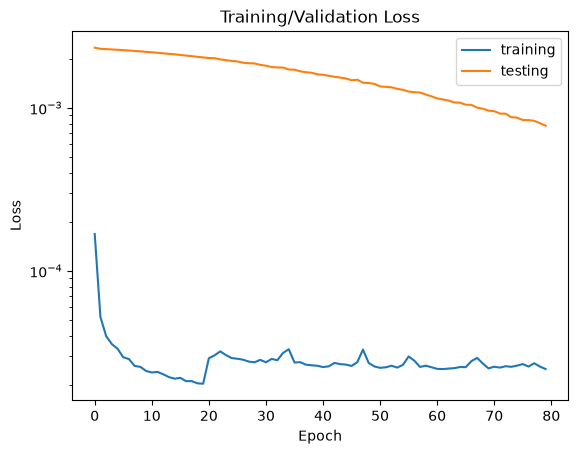

Epoch 81/200, Train Loss: 0.00002646, Test Loss: 0.00077048, SpecErr: 4.9141e+00, Time: 18.24s, LR: 6.70e-04
Epoch 82/200, Train Loss: 0.00002848, Test Loss: 0.00077054, SpecErr: 5.1218e+00, Time: 18.22s, LR: 6.62e-04
Epoch 83/200, Train Loss: 0.00002842, Test Loss: 0.00072528, SpecErr: 4.1693e+00, Time: 18.46s, LR: 6.55e-04
Epoch 84/200, Train Loss: 0.00002511, Test Loss: 0.00071789, SpecErr: 3.9940e+00, Time: 18.35s, LR: 6.47e-04
Epoch 85/200, Train Loss: 0.00002482, Test Loss: 0.00069354, SpecErr: 3.8864e+00, Time: 18.29s, LR: 6.39e-04
Epoch 86/200, Train Loss: 0.00002431, Test Loss: 0.00069311, SpecErr: 3.8609e+00, Time: 18.31s, LR: 6.31e-04
Epoch 87/200, Train Loss: 0.00002442, Test Loss: 0.00067068, SpecErr: 3.7464e+00, Time: 18.06s, LR: 6.24e-04
Epoch 88/200, Train Loss: 0.00002455, Test Loss: 0.00066213, SpecErr: 3.8204e+00, Time: 17.79s, LR: 6.16e-04
Epoch 89/200, Train Loss: 0.00002561, Test Loss: 0.00065441, SpecErr: 3.7611e+00, Time: 19.47s, LR: 6.08e-04
  L_pixel=1.874e-01

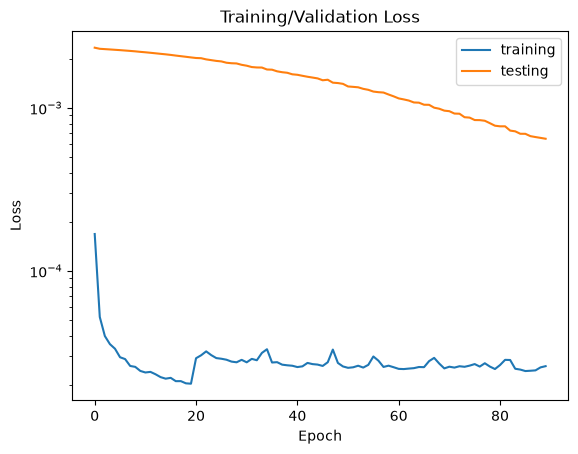

Epoch 91/200, Train Loss: 0.00002860, Test Loss: 0.00060425, SpecErr: 2.9908e+00, Time: 20.11s, LR: 5.92e-04
Epoch 92/200, Train Loss: 0.00002575, Test Loss: 0.00061168, SpecErr: 3.4281e+00, Time: 20.30s, LR: 5.84e-04
Epoch 93/200, Train Loss: 0.00002566, Test Loss: 0.00058939, SpecErr: 2.9908e+00, Time: 18.61s, LR: 5.76e-04
Epoch 94/200, Train Loss: 0.00002624, Test Loss: 0.00057823, SpecErr: 3.0288e+00, Time: 18.63s, LR: 5.68e-04
Epoch 95/200, Train Loss: 0.00002567, Test Loss: 0.00057003, SpecErr: 3.0463e+00, Time: 18.54s, LR: 5.60e-04
Epoch 96/200, Train Loss: 0.00002526, Test Loss: 0.00056111, SpecErr: 2.9658e+00, Time: 18.45s, LR: 5.52e-04
Epoch 97/200, Train Loss: 0.00002635, Test Loss: 0.00053695, SpecErr: 2.6703e+00, Time: 18.65s, LR: 5.44e-04
Epoch 98/200, Train Loss: 0.00002639, Test Loss: 0.00052768, SpecErr: 2.5824e+00, Time: 18.72s, LR: 5.36e-04
Epoch 99/200, Train Loss: 0.00002539, Test Loss: 0.00051563, SpecErr: 2.5407e+00, Time: 18.44s, LR: 5.28e-04
  L_pixel=1.858e-01

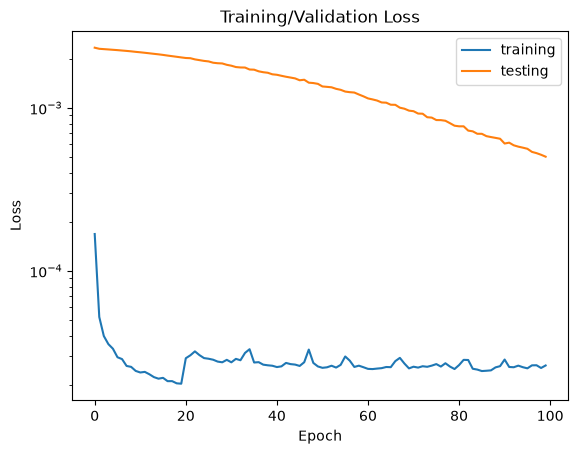

Epoch 101/200, Train Loss: 0.00002483, Test Loss: 0.00048237, SpecErr: 2.0623e+00, Time: 18.84s, LR: 5.12e-04
Epoch 102/200, Train Loss: 0.00002432, Test Loss: 0.00048387, SpecErr: 2.1734e+00, Time: 18.79s, LR: 5.04e-04
Epoch 103/200, Train Loss: 0.00002423, Test Loss: 0.00047351, SpecErr: 2.0732e+00, Time: 18.63s, LR: 4.96e-04
Epoch 104/200, Train Loss: 0.00002414, Test Loss: 0.00046247, SpecErr: 1.8932e+00, Time: 18.32s, LR: 4.88e-04
Epoch 105/200, Train Loss: 0.00002473, Test Loss: 0.00045588, SpecErr: 1.9217e+00, Time: 18.33s, LR: 4.80e-04
Epoch 106/200, Train Loss: 0.00002504, Test Loss: 0.00045728, SpecErr: 2.0360e+00, Time: 18.32s, LR: 4.72e-04
Epoch 107/200, Train Loss: 0.00002623, Test Loss: 0.00044119, SpecErr: 1.8211e+00, Time: 18.41s, LR: 4.64e-04
Epoch 108/200, Train Loss: 0.00002485, Test Loss: 0.00043001, SpecErr: 1.7393e+00, Time: 21.35s, LR: 4.56e-04
Epoch 109/200, Train Loss: 0.00002435, Test Loss: 0.00042907, SpecErr: 1.8191e+00, Time: 20.00s, LR: 4.48e-04
  L_pixel=

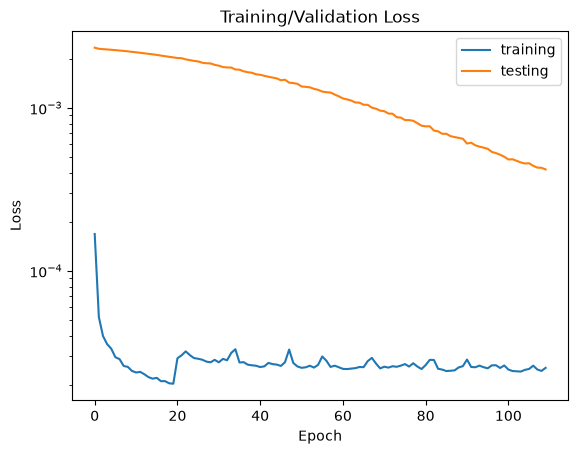

Epoch 111/200, Train Loss: 0.00002605, Test Loss: 0.00040799, SpecErr: 1.6787e+00, Time: 22.22s, LR: 4.32e-04
Epoch 112/200, Train Loss: 0.00002685, Test Loss: 0.00039706, SpecErr: 1.4472e+00, Time: 22.19s, LR: 4.24e-04
Epoch 113/200, Train Loss: 0.00002531, Test Loss: 0.00038871, SpecErr: 1.4321e+00, Time: 19.68s, LR: 4.16e-04
Epoch 114/200, Train Loss: 0.00002557, Test Loss: 0.00038227, SpecErr: 1.4732e+00, Time: 19.20s, LR: 4.08e-04
Epoch 115/200, Train Loss: 0.00002369, Test Loss: 0.00037904, SpecErr: 1.4114e+00, Time: 18.63s, LR: 4.00e-04
Epoch 116/200, Train Loss: 0.00002455, Test Loss: 0.00037784, SpecErr: 1.4465e+00, Time: 18.83s, LR: 3.92e-04
Epoch 117/200, Train Loss: 0.00002663, Test Loss: 0.00038363, SpecErr: 1.6796e+00, Time: 18.70s, LR: 3.84e-04
Epoch 118/200, Train Loss: 0.00002613, Test Loss: 0.00035771, SpecErr: 1.2892e+00, Time: 18.54s, LR: 3.76e-04
Epoch 119/200, Train Loss: 0.00002560, Test Loss: 0.00034319, SpecErr: 1.1045e+00, Time: 18.71s, LR: 3.69e-04
  L_pixel=

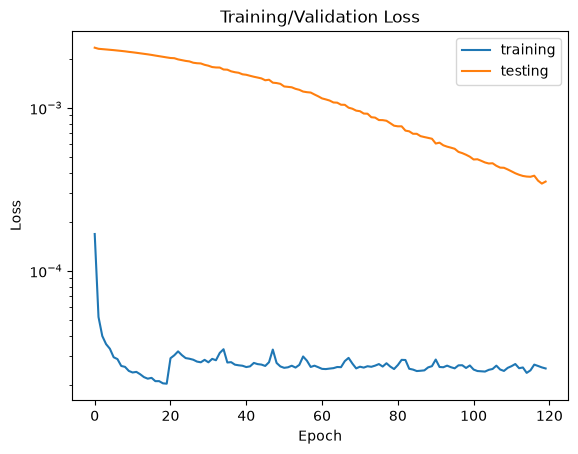

Epoch 121/200, Train Loss: 0.00002495, Test Loss: 0.00034165, SpecErr: 1.1209e+00, Time: 18.81s, LR: 3.53e-04
Epoch 122/200, Train Loss: 0.00002590, Test Loss: 0.00032376, SpecErr: 9.2610e-01, Time: 18.57s, LR: 3.45e-04
Epoch 123/200, Train Loss: 0.00002706, Test Loss: 0.00032862, SpecErr: 1.0722e+00, Time: 18.68s, LR: 3.38e-04
Epoch 124/200, Train Loss: 0.00002479, Test Loss: 0.00031873, SpecErr: 9.4024e-01, Time: 18.47s, LR: 3.30e-04
Epoch 125/200, Train Loss: 0.00002529, Test Loss: 0.00031637, SpecErr: 9.3945e-01, Time: 18.58s, LR: 3.23e-04
Epoch 126/200, Train Loss: 0.00002556, Test Loss: 0.00031894, SpecErr: 9.8906e-01, Time: 17.75s, LR: 3.15e-04
Epoch 127/200, Train Loss: 0.00002653, Test Loss: 0.00030632, SpecErr: 8.0545e-01, Time: 16.75s, LR: 3.08e-04
Epoch 128/200, Train Loss: 0.00002514, Test Loss: 0.00030692, SpecErr: 8.5227e-01, Time: 18.98s, LR: 3.00e-04
Epoch 129/200, Train Loss: 0.00002485, Test Loss: 0.00029932, SpecErr: 7.5136e-01, Time: 19.69s, LR: 2.93e-04
  L_pixel=

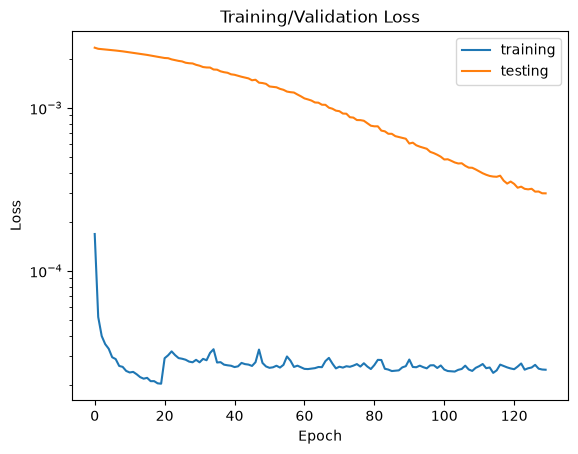

Epoch 131/200, Train Loss: 0.00002446, Test Loss: 0.00029100, SpecErr: 6.9016e-01, Time: 20.21s, LR: 2.78e-04
Epoch 132/200, Train Loss: 0.00002537, Test Loss: 0.00028971, SpecErr: 7.8203e-01, Time: 18.61s, LR: 2.71e-04
Epoch 133/200, Train Loss: 0.00002822, Test Loss: 0.00029319, SpecErr: 6.8549e-01, Time: 18.86s, LR: 2.64e-04
Epoch 134/200, Train Loss: 0.00002473, Test Loss: 0.00028646, SpecErr: 5.4724e-01, Time: 19.21s, LR: 2.57e-04
Epoch 135/200, Train Loss: 0.00002331, Test Loss: 0.00028144, SpecErr: 6.2461e-01, Time: 21.95s, LR: 2.50e-04
Epoch 136/200, Train Loss: 0.00002384, Test Loss: 0.00028004, SpecErr: 6.3743e-01, Time: 22.38s, LR: 2.43e-04
Epoch 137/200, Train Loss: 0.00002405, Test Loss: 0.00027735, SpecErr: 6.6355e-01, Time: 22.29s, LR: 2.36e-04
Epoch 138/200, Train Loss: 0.00002389, Test Loss: 0.00027389, SpecErr: 6.6341e-01, Time: 21.41s, LR: 2.29e-04
Epoch 139/200, Train Loss: 0.00002430, Test Loss: 0.00027339, SpecErr: 5.7968e-01, Time: 21.18s, LR: 2.23e-04
  L_pixel=

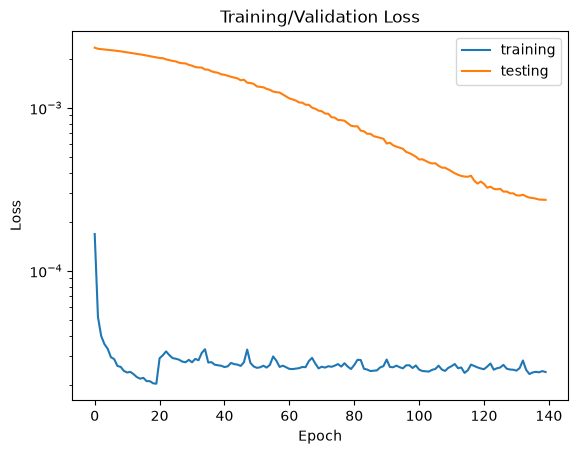

Epoch 141/200, Train Loss: 0.00002474, Test Loss: 0.00026792, SpecErr: 5.8725e-01, Time: 18.88s, LR: 2.09e-04
Epoch 142/200, Train Loss: 0.00002562, Test Loss: 0.00026786, SpecErr: 6.0333e-01, Time: 18.47s, LR: 2.03e-04
Epoch 143/200, Train Loss: 0.00002536, Test Loss: 0.00026691, SpecErr: 5.5181e-01, Time: 18.79s, LR: 1.96e-04
Epoch 144/200, Train Loss: 0.00002569, Test Loss: 0.00026385, SpecErr: 4.2195e-01, Time: 18.86s, LR: 1.90e-04
Epoch 145/200, Train Loss: 0.00002441, Test Loss: 0.00026085, SpecErr: 4.1653e-01, Time: 19.03s, LR: 1.84e-04
Epoch 146/200, Train Loss: 0.00002360, Test Loss: 0.00025872, SpecErr: 4.0889e-01, Time: 18.64s, LR: 1.78e-04
Epoch 147/200, Train Loss: 0.00002360, Test Loss: 0.00025735, SpecErr: 3.5984e-01, Time: 19.57s, LR: 1.71e-04
Epoch 148/200, Train Loss: 0.00002453, Test Loss: 0.00025551, SpecErr: 4.3276e-01, Time: 20.16s, LR: 1.65e-04
Epoch 149/200, Train Loss: 0.00002537, Test Loss: 0.00025600, SpecErr: 4.3734e-01, Time: 20.28s, LR: 1.59e-04
  L_pixel=

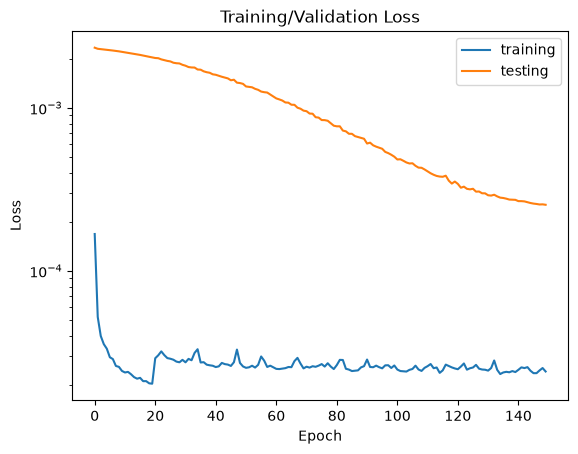

Epoch 151/200, Train Loss: 0.00002398, Test Loss: 0.00025337, SpecErr: 3.4790e-01, Time: 20.01s, LR: 1.48e-04
Epoch 152/200, Train Loss: 0.00002295, Test Loss: 0.00025251, SpecErr: 3.6627e-01, Time: 16.84s, LR: 1.42e-04
Epoch 153/200, Train Loss: 0.00002301, Test Loss: 0.00025059, SpecErr: 3.5065e-01, Time: 16.70s, LR: 1.37e-04
Epoch 154/200, Train Loss: 0.00002355, Test Loss: 0.00025153, SpecErr: 3.3013e-01, Time: 16.68s, LR: 1.31e-04
Epoch 155/200, Train Loss: 0.00002382, Test Loss: 0.00024987, SpecErr: 3.2647e-01, Time: 16.67s, LR: 1.26e-04
Epoch 156/200, Train Loss: 0.00002627, Test Loss: 0.00024834, SpecErr: 3.1662e-01, Time: 16.72s, LR: 1.20e-04
Epoch 157/200, Train Loss: 0.00002587, Test Loss: 0.00024906, SpecErr: 3.2438e-01, Time: 16.72s, LR: 1.15e-04
Epoch 158/200, Train Loss: 0.00002436, Test Loss: 0.00024851, SpecErr: 2.9351e-01, Time: 16.56s, LR: 1.10e-04
Epoch 159/200, Train Loss: 0.00002332, Test Loss: 0.00024859, SpecErr: 3.1031e-01, Time: 18.67s, LR: 1.05e-04
  L_pixel=

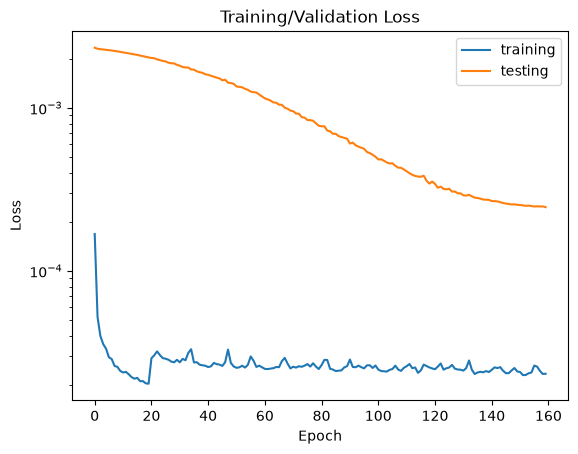

Epoch 161/200, Train Loss: 0.00002365, Test Loss: 0.00024456, SpecErr: 3.2781e-01, Time: 18.24s, LR: 9.55e-05
Epoch 162/200, Train Loss: 0.00002442, Test Loss: 0.00024456, SpecErr: 3.0421e-01, Time: 18.26s, LR: 9.08e-05
Epoch 163/200, Train Loss: 0.00002583, Test Loss: 0.00024305, SpecErr: 3.4283e-01, Time: 18.60s, LR: 8.62e-05
Epoch 164/200, Train Loss: 0.00002632, Test Loss: 0.00024272, SpecErr: 2.9009e-01, Time: 18.47s, LR: 8.18e-05
Epoch 165/200, Train Loss: 0.00002506, Test Loss: 0.00024382, SpecErr: 2.5087e-01, Time: 17.32s, LR: 7.74e-05
Epoch 166/200, Train Loss: 0.00002386, Test Loss: 0.00024394, SpecErr: 2.4980e-01, Time: 18.00s, LR: 7.32e-05
Epoch 167/200, Train Loss: 0.00002362, Test Loss: 0.00024377, SpecErr: 2.3387e-01, Time: 18.09s, LR: 6.90e-05
Epoch 168/200, Train Loss: 0.00002359, Test Loss: 0.00024285, SpecErr: 2.3479e-01, Time: 16.79s, LR: 6.50e-05
Epoch 169/200, Train Loss: 0.00002420, Test Loss: 0.00024110, SpecErr: 2.6549e-01, Time: 17.58s, LR: 6.11e-05
  L_pixel=

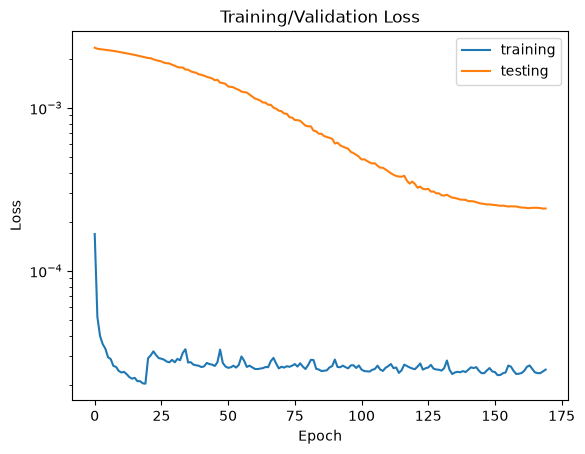

Epoch 171/200, Train Loss: 0.00002441, Test Loss: 0.00024222, SpecErr: 2.2881e-01, Time: 16.78s, LR: 5.36e-05
Epoch 172/200, Train Loss: 0.00002455, Test Loss: 0.00024194, SpecErr: 2.2957e-01, Time: 16.95s, LR: 5.00e-05
Epoch 173/200, Train Loss: 0.00002484, Test Loss: 0.00024378, SpecErr: 1.8434e-01, Time: 17.33s, LR: 4.66e-05
Epoch 174/200, Train Loss: 0.00002423, Test Loss: 0.00024434, SpecErr: 1.7589e-01, Time: 17.14s, LR: 4.32e-05
Epoch 175/200, Train Loss: 0.00002418, Test Loss: 0.00024411, SpecErr: 1.7588e-01, Time: 16.94s, LR: 4.00e-05
Epoch 176/200, Train Loss: 0.00002426, Test Loss: 0.00024272, SpecErr: 2.0248e-01, Time: 16.75s, LR: 3.69e-05
Epoch 177/200, Train Loss: 0.00002540, Test Loss: 0.00024188, SpecErr: 2.1045e-01, Time: 16.90s, LR: 3.39e-05
Epoch 178/200, Train Loss: 0.00002543, Test Loss: 0.00023879, SpecErr: 2.4269e-01, Time: 17.06s, LR: 3.11e-05
Epoch 179/200, Train Loss: 0.00002559, Test Loss: 0.00024114, SpecErr: 1.9328e-01, Time: 18.33s, LR: 2.83e-05
  L_pixel=

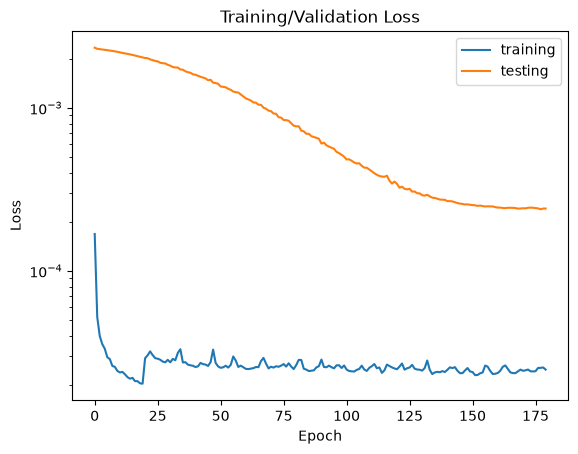

Epoch 181/200, Train Loss: 0.00002367, Test Loss: 0.00024300, SpecErr: 1.6468e-01, Time: 21.69s, LR: 2.32e-05
Epoch 182/200, Train Loss: 0.00002350, Test Loss: 0.00024378, SpecErr: 1.5309e-01, Time: 19.82s, LR: 2.09e-05
Epoch 183/200, Train Loss: 0.00002371, Test Loss: 0.00024221, SpecErr: 1.6471e-01, Time: 19.96s, LR: 1.86e-05
Epoch 184/200, Train Loss: 0.00002379, Test Loss: 0.00024271, SpecErr: 1.6191e-01, Time: 19.12s, LR: 1.65e-05
Epoch 185/200, Train Loss: 0.00002402, Test Loss: 0.00024261, SpecErr: 1.5563e-01, Time: 19.80s, LR: 1.45e-05
Epoch 186/200, Train Loss: 0.00002411, Test Loss: 0.00024241, SpecErr: 1.5887e-01, Time: 19.60s, LR: 1.27e-05
Epoch 187/200, Train Loss: 0.00002408, Test Loss: 0.00024120, SpecErr: 1.7196e-01, Time: 19.66s, LR: 1.09e-05
Epoch 188/200, Train Loss: 0.00002410, Test Loss: 0.00024223, SpecErr: 1.5745e-01, Time: 20.93s, LR: 9.31e-06
Epoch 189/200, Train Loss: 0.00002426, Test Loss: 0.00024157, SpecErr: 1.6158e-01, Time: 20.46s, LR: 7.83e-06
  L_pixel=

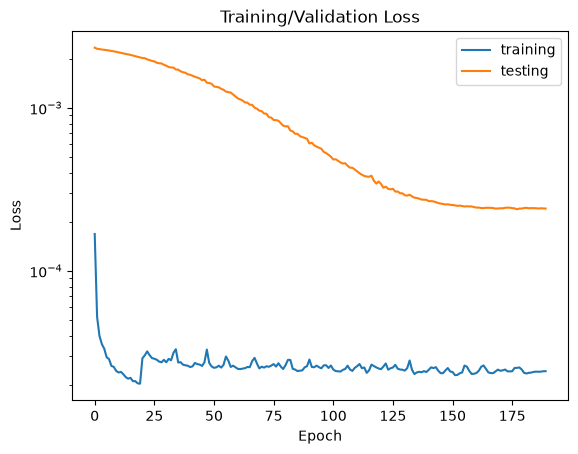

Epoch 191/200, Train Loss: 0.00002433, Test Loss: 0.00024106, SpecErr: 1.5986e-01, Time: 18.72s, LR: 5.25e-06
Epoch 192/200, Train Loss: 0.00002435, Test Loss: 0.00024148, SpecErr: 1.5842e-01, Time: 18.70s, LR: 4.15e-06
Epoch 193/200, Train Loss: 0.00002441, Test Loss: 0.00024080, SpecErr: 1.6229e-01, Time: 18.64s, LR: 3.18e-06
Epoch 194/200, Train Loss: 0.00002448, Test Loss: 0.00024178, SpecErr: 1.5332e-01, Time: 18.49s, LR: 2.33e-06
Epoch 195/200, Train Loss: 0.00002453, Test Loss: 0.00024106, SpecErr: 1.5651e-01, Time: 19.57s, LR: 1.62e-06
Epoch 196/200, Train Loss: 0.00002451, Test Loss: 0.00024096, SpecErr: 1.5750e-01, Time: 20.79s, LR: 1.04e-06
Epoch 197/200, Train Loss: 0.00002449, Test Loss: 0.00024079, SpecErr: 1.5681e-01, Time: 19.69s, LR: 5.84e-07
Epoch 198/200, Train Loss: 0.00002447, Test Loss: 0.00024149, SpecErr: 1.5178e-01, Time: 18.60s, LR: 2.60e-07
Epoch 199/200, Train Loss: 0.00002450, Test Loss: 0.00024240, SpecErr: 1.4294e-01, Time: 18.45s, LR: 6.49e-08
  L_pixel=

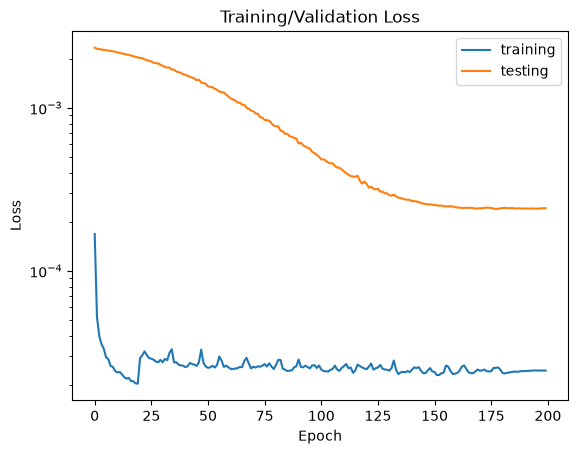

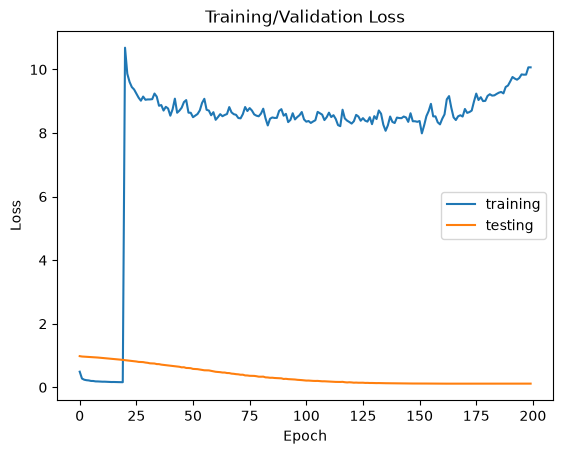

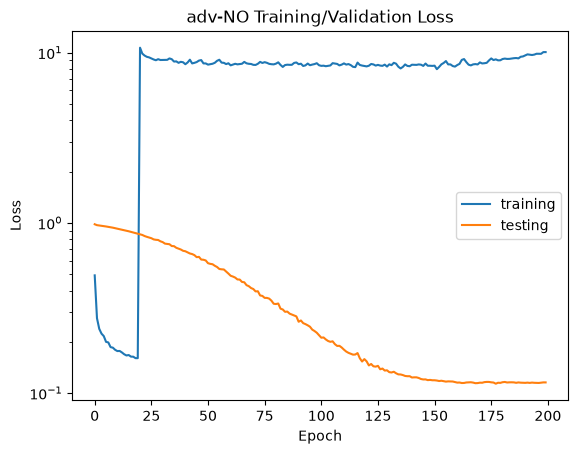

In [19]:
# === With adv-NO ===
adv_tags = "BASELINE_ADV_NO"

model_adv = U_net(
    input_channels=2, output_channels=2,
    kernel_size=5, dropout_rate=0.2,
).to(device)

print(f"adv-NO generator params: {count_params(model_adv)}")
a_train_losses, a_test_losses, a_best_spec = train_recursive(
    model_adv,
    train_loader,
    test_loader,
    num_steps=T_out,
    num_epochs=epochs,
    plot_interval=10,
    teacher_forcing=False,
    clip_grad=0.5,
    early_stopping_patience=30,
    u_x_std=u_x_std,
    u_y_std=u_y_std,
    use_pita=False,
    use_adv=True,
    adv_warmup_epochs=20,
    adv_beta=0.1,
    adv_use_perceptual=True,
    adv_max_frames=16,
)
# a_best_spec is spectrum error, not MSE
# train loss jumps at adv_warmup_epochs since the loss changes there

plt.plot(a_train_losses, label="training")
plt.plot(a_test_losses, label="testing")
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('adv-NO Training/Validation Loss')
plt.legend()
plt.show()



## Evaluating and saving


Defining a function to run the fully trained model on our test data.

In [20]:
def test_recursive(model, dataloader, num_steps=10):
    # We want to put the model in evaluate mode now to get rid of any
    model.eval()
    u_actual = []
    u_pred = []
    with torch.no_grad():
      for batch in dataloader:
          # Expected batch keys:
          # 'u0': initial velocity field, shape (batch_size, 2, 89, 144)
          # 'targets': ground truth evolution for next num_steps timesteps,
          #            shape (batch_size, num_steps, 2, 89, 144)
          u0 = batch['u0'].to(device)
          targets = batch['targets'].to(device)
          u_actual.append(torch.cat((u0.unsqueeze(1), targets), dim=1))

          predictions = recursive_prediction(model, u0, num_steps=num_steps)
          u_pred.append(torch.stack(predictions, dim=1))
          # predictions is a list of length (num_steps+1): first element is u0, then each future timestep
    plot_velocity_field(predictions)
    u_actual = torch.cat(u_actual, dim=0).permute(2, 0, 3, 4, 1)
    u_pred = torch.cat(u_pred, dim=0).permute(2, 0, 3, 4, 1)
    return u_actual, u_pred



Run this and save it

In [21]:
from datetime import date, datetime
from pathlib import Path

# runs are saved to outputs/<model_name>/ with a timestamp prefix
OUTPUT_ROOT = Path('./outputs')

def save_run(model, model_name, train_losses, test_losses, tag, num_steps=None):
    # roll out on the test set, save .h5 results and .pt model
    num_steps = T_out if num_steps is None else num_steps
    out_dir = OUTPUT_ROOT / model_name
    out_dir.mkdir(parents=True, exist_ok=True)

    stamp = datetime.now().strftime('%Y%m%d-%H%M%S')
    base = f'{stamp}_{model_name}_{epochs}epoch_bs{batch_size}_{speed}_{tag}'

    u_actual, u_pred = test_recursive(model, test_loader, num_steps=num_steps)

    h5_path = out_dir / f'{base}.h5'
    with h5py.File(h5_path, 'w') as f:
        f.create_dataset('u_actual',     data=u_actual.cpu().numpy())
        f.create_dataset('u_pred',       data=u_pred.cpu().numpy())
        f.create_dataset('train_losses', data=np.array(train_losses))
        f.create_dataset('test_losses',  data=np.array(test_losses))
        f.create_dataset('u_x_mean',     data=u_x_mean)
        f.create_dataset('u_x_std',      data=u_x_std)
        f.create_dataset('u_y_mean',     data=u_y_mean)
        f.create_dataset('u_y_std',      data=u_y_std)
        f.attrs['model_name'] = model_name
        f.attrs['tag']        = tag
        f.attrs['epochs']     = epochs
        f.attrs['batch_size'] = batch_size
        f.attrs['speed']      = speed
        f.attrs['timestamp']  = stamp
        f.attrs['seed']       = seed
        f.attrs['T_in']       = T_in
        f.attrs['T_out']      = T_out

    pt_path = out_dir / f'{base}.pt'
    torch.save(model, pt_path)

    print(f"{model_name}: saved\n  {h5_path}\n  {pt_path}")
    return h5_path, pt_path, u_actual, u_pred

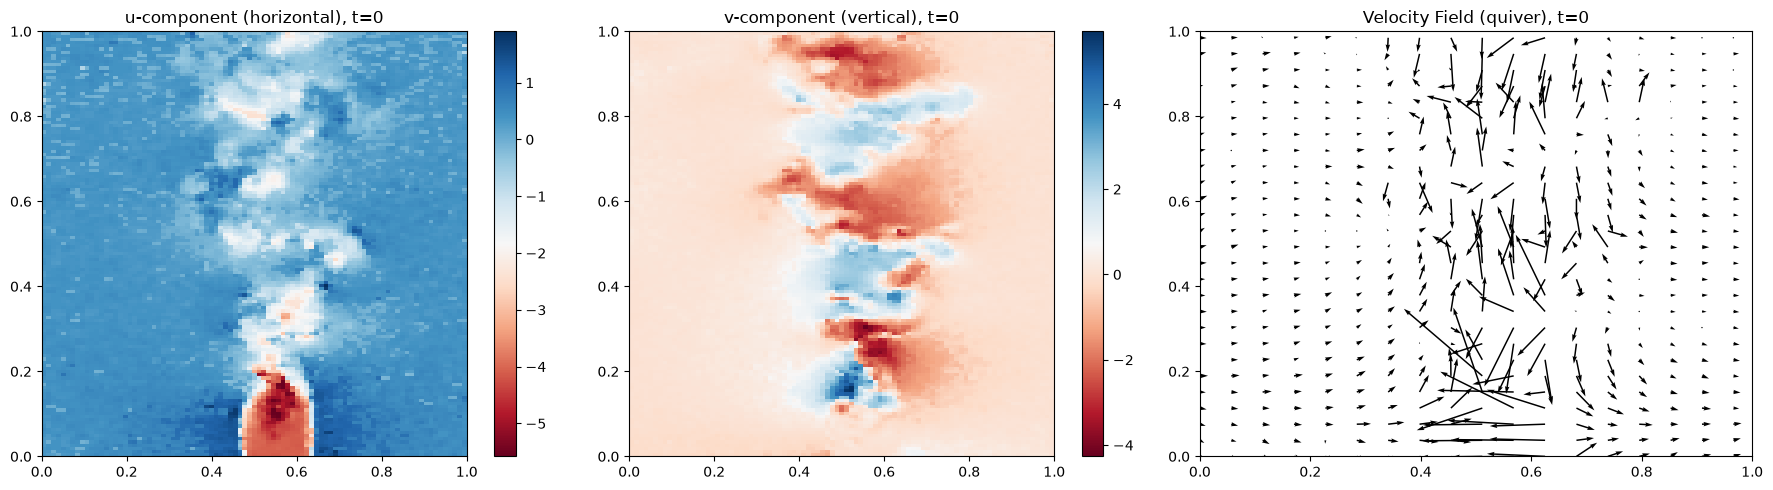

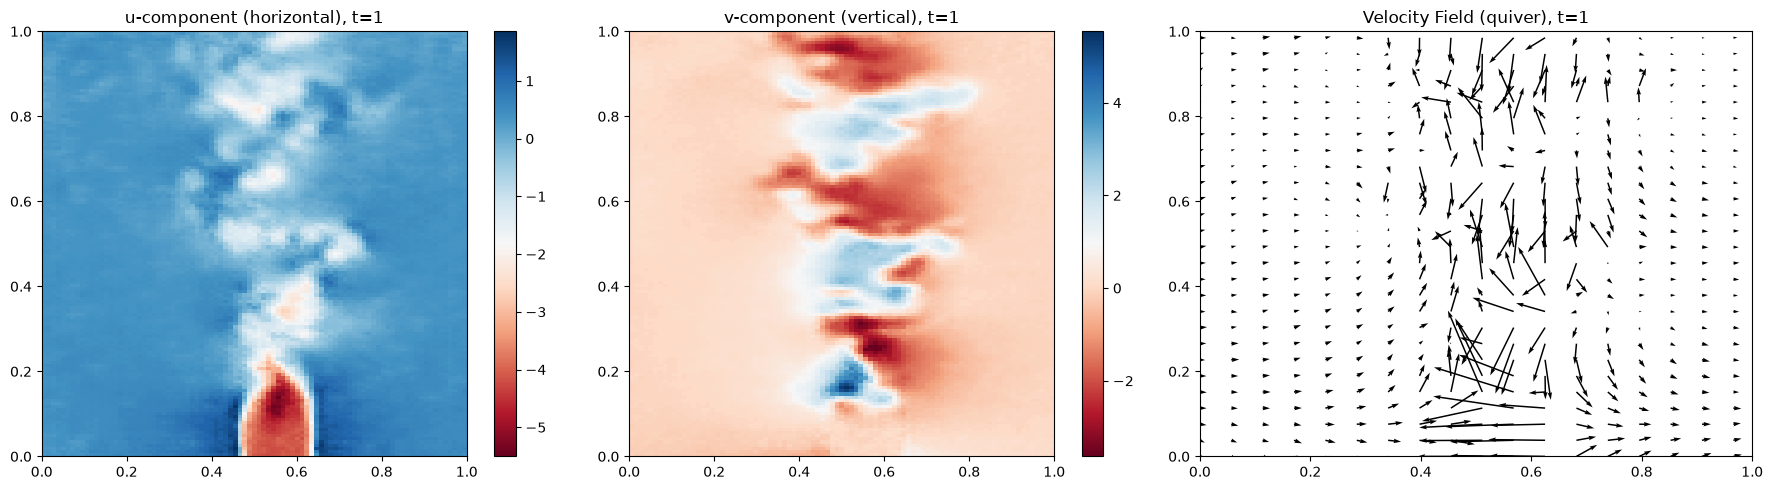

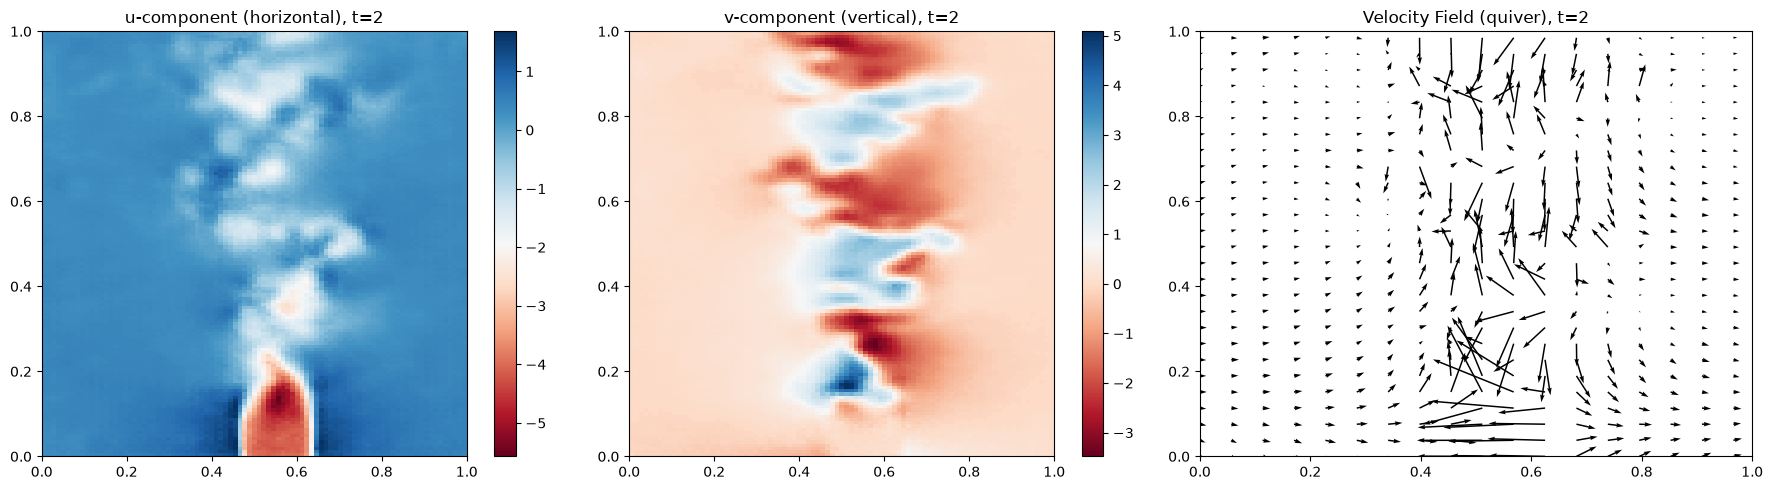

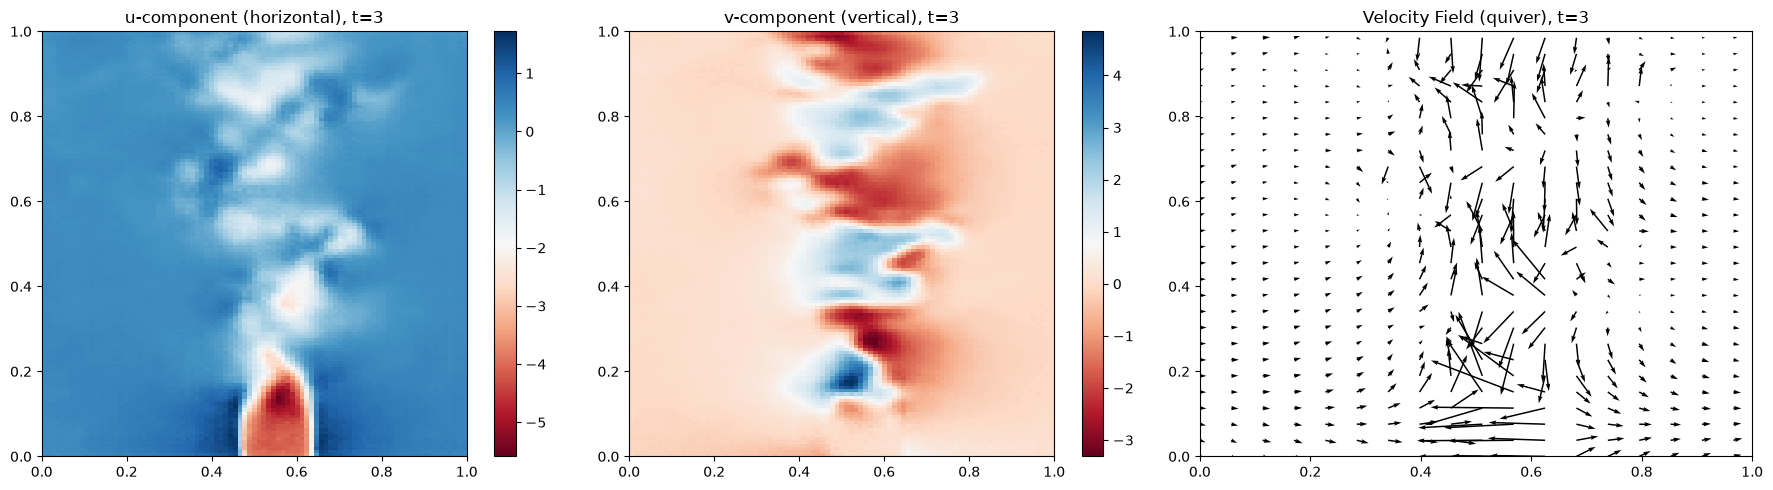

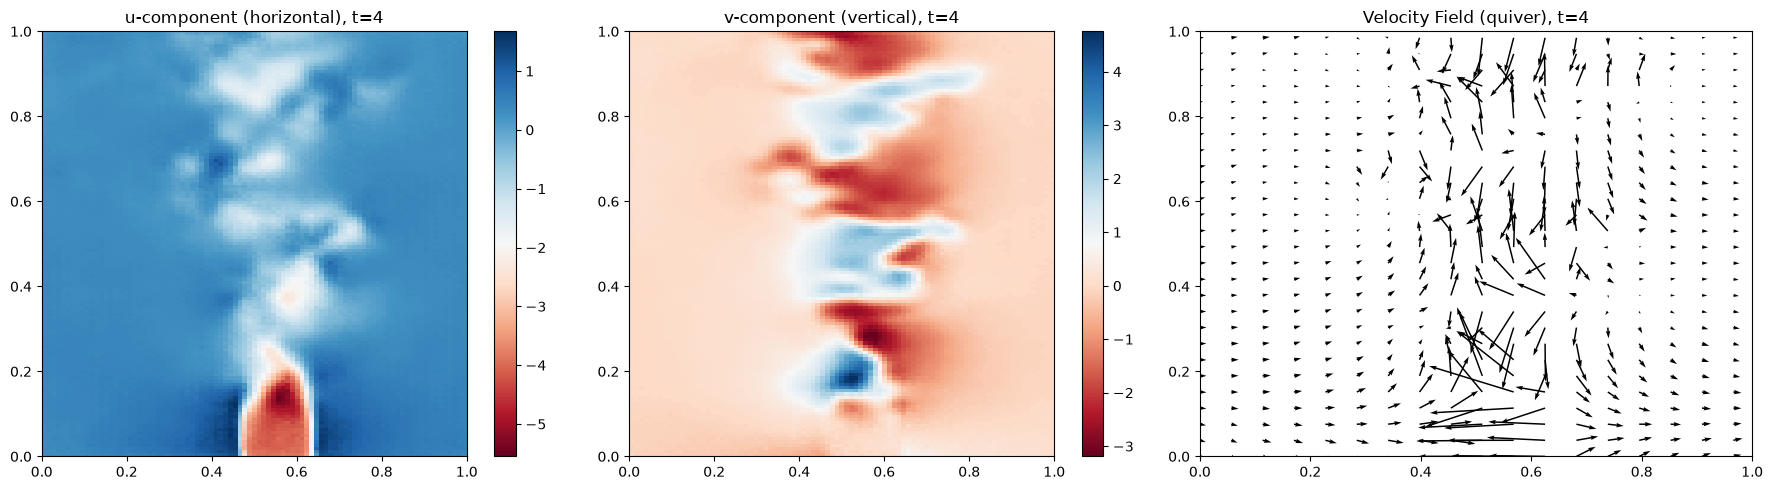

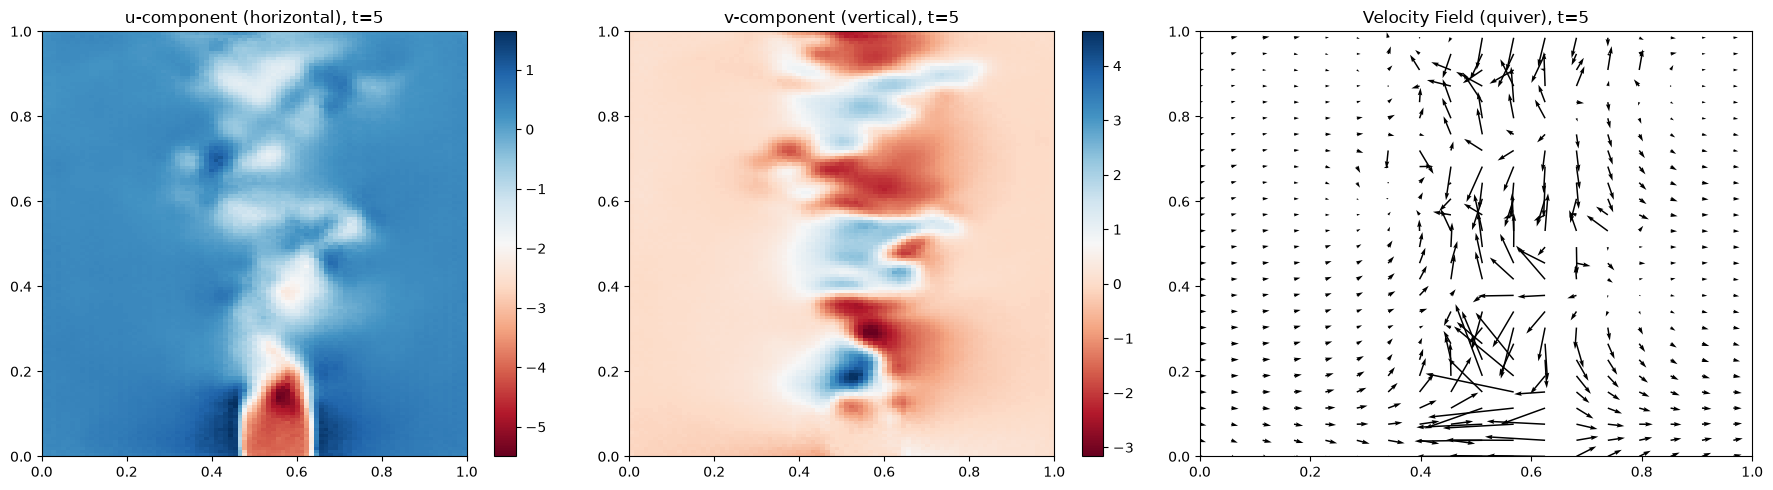

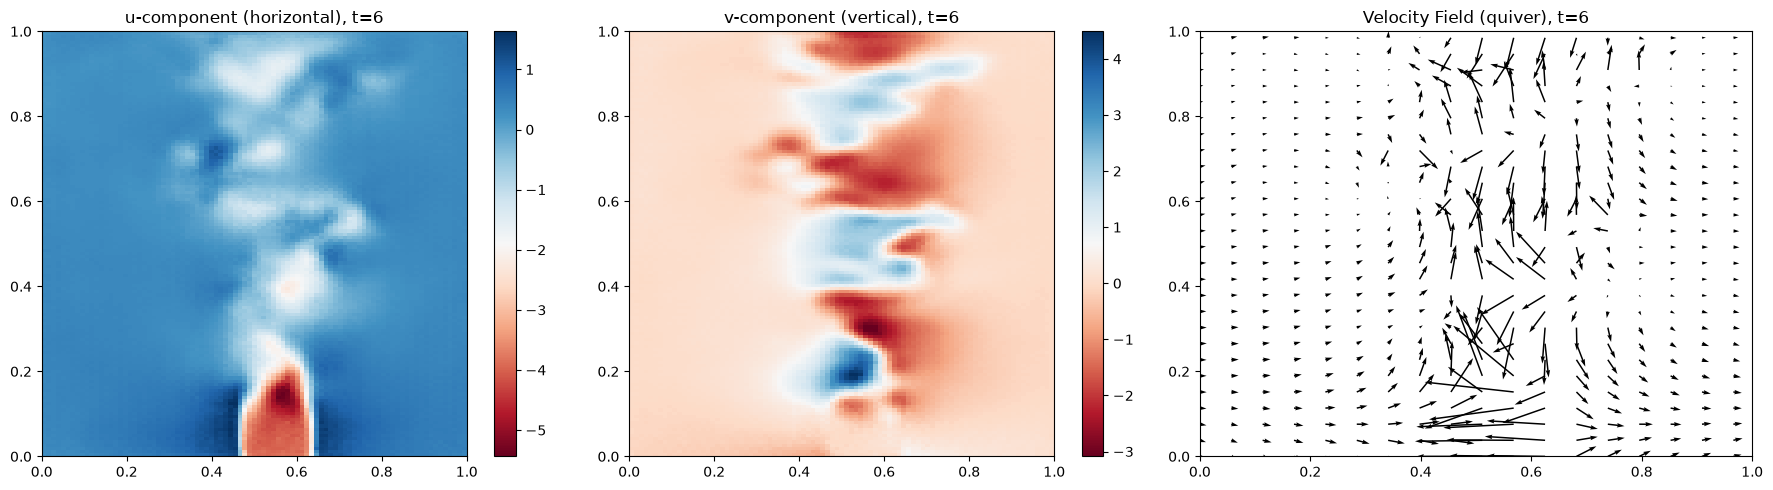

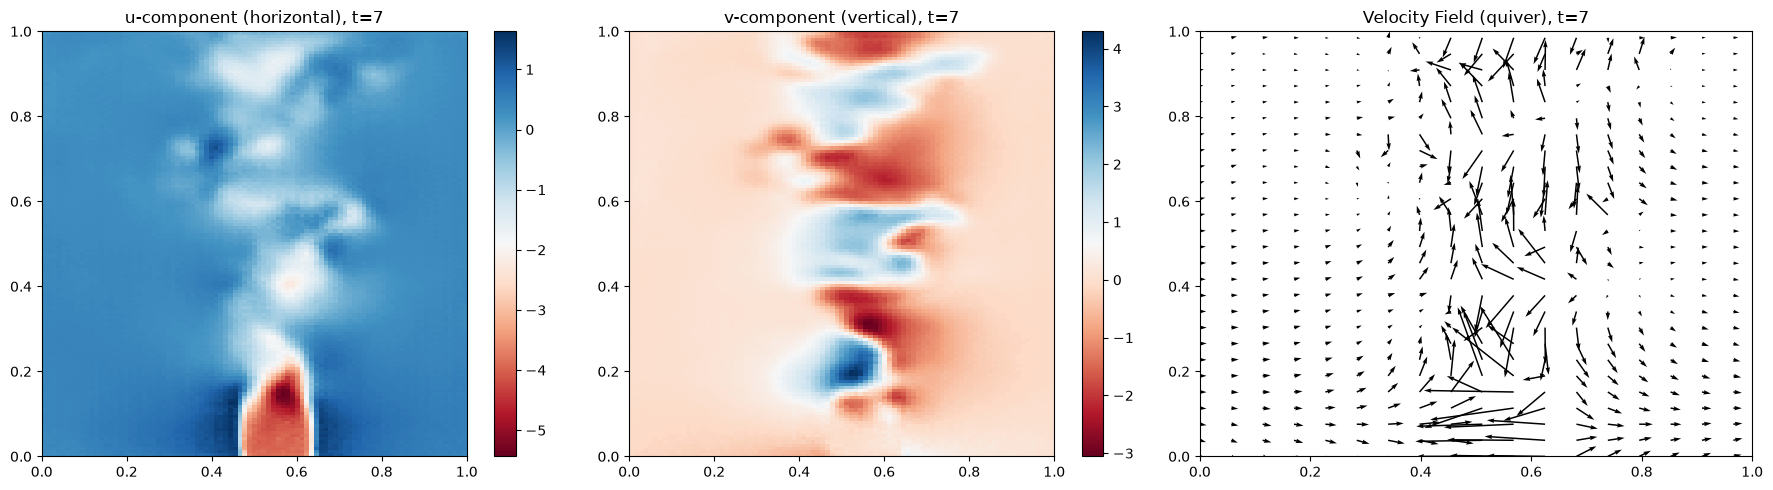

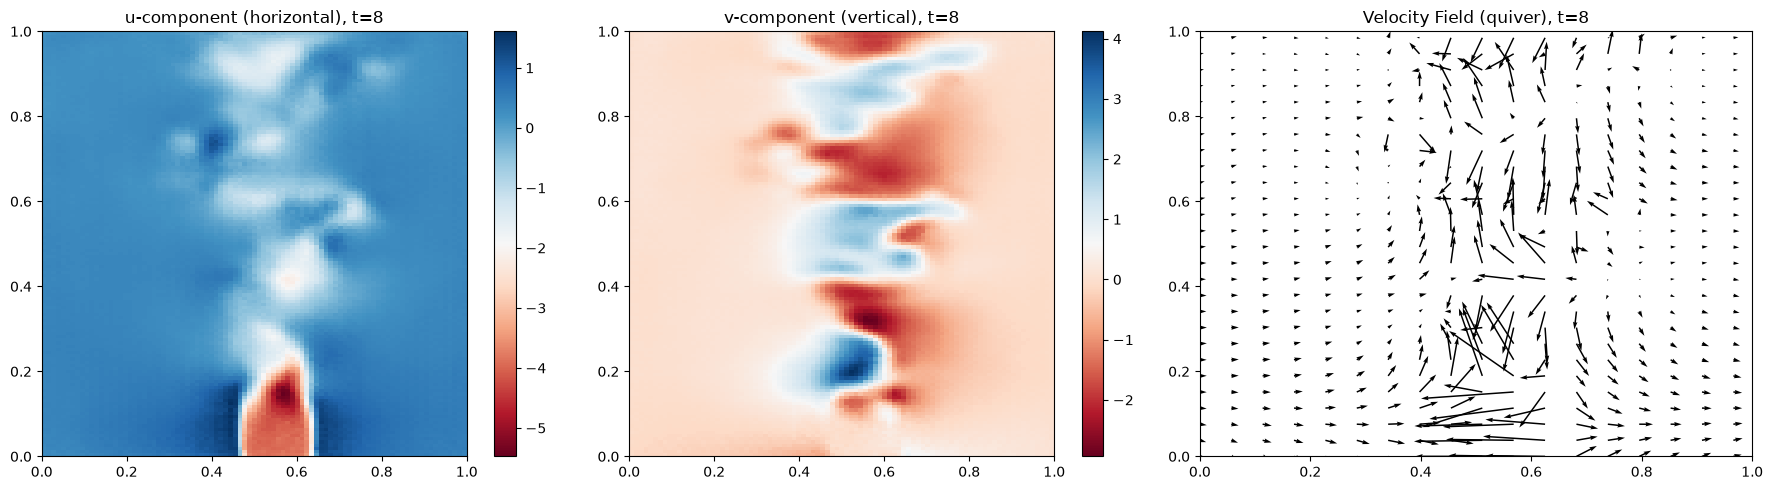

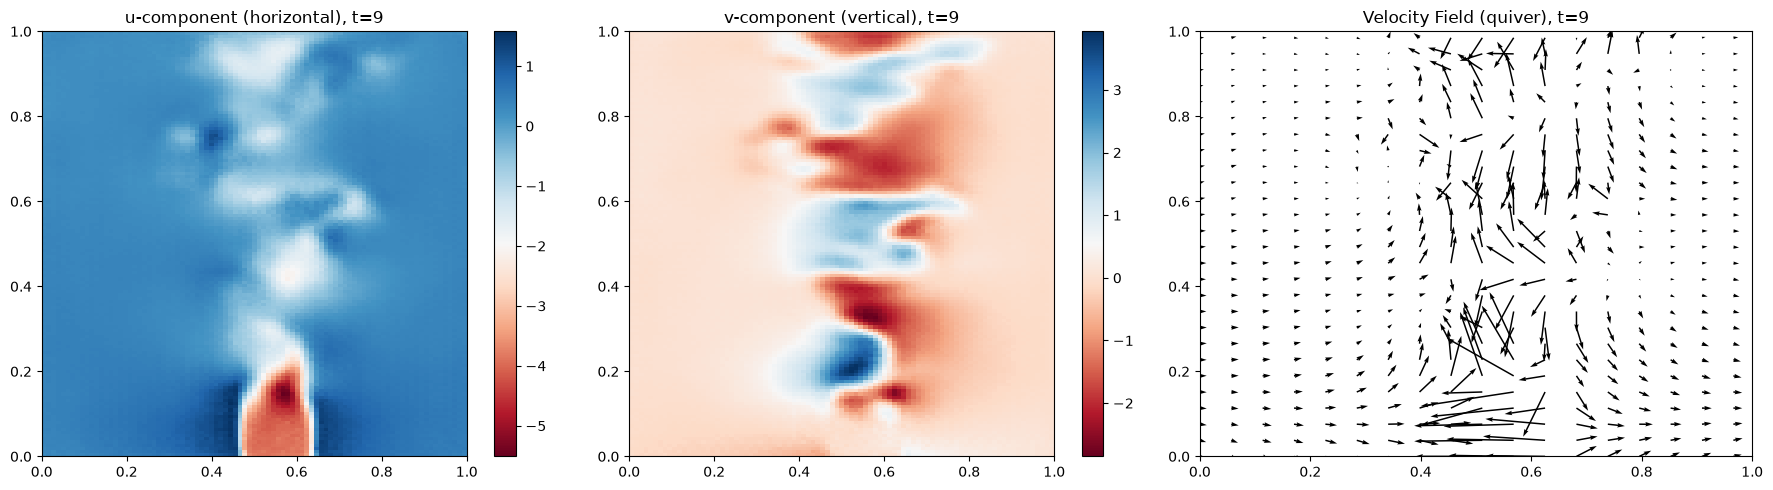

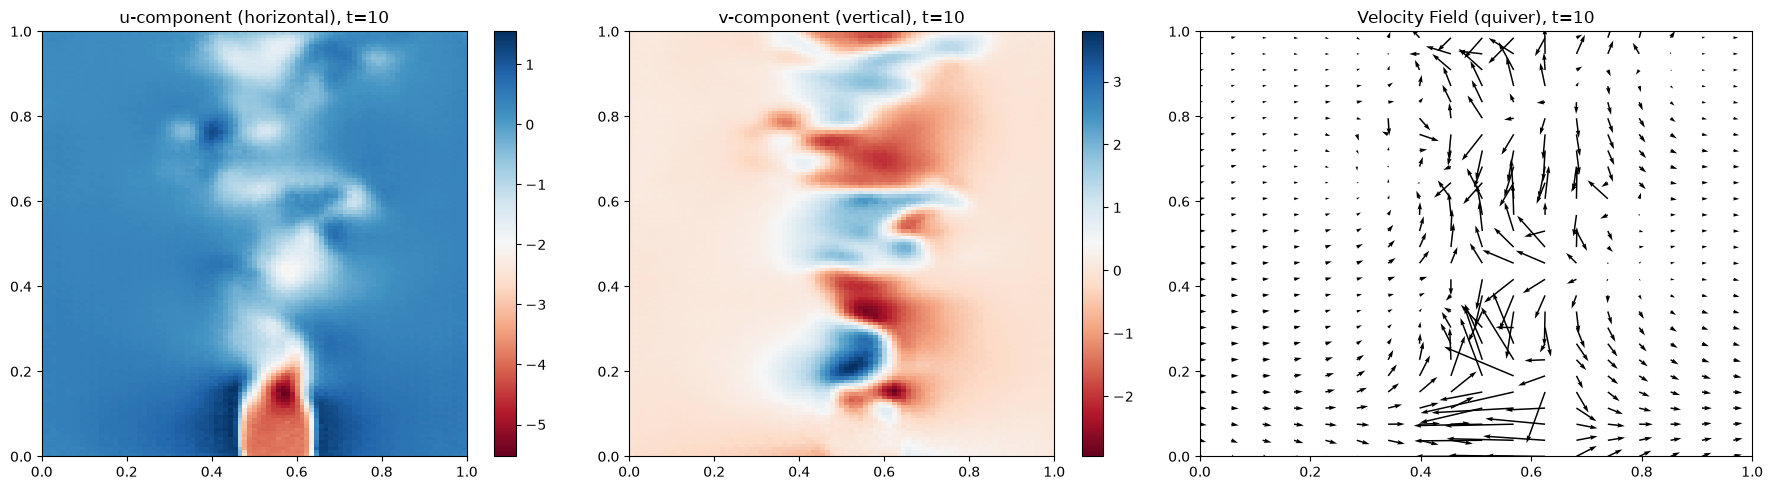

UNet: saved
  outputs/UNet/20260907-211749_UNet_200epoch_bs16_5Hz_200fps_BASELINE_NO_PITA.h5
  outputs/UNet/20260907-211749_UNet_200epoch_bs16_5Hz_200fps_BASELINE_NO_PITA.pt


In [22]:
# save baseline
b_h5, b_pt, b_u_actual, b_u_pred = save_run(
    model_base, 'UNet', b_train_losses, b_test_losses, baseline_tags)


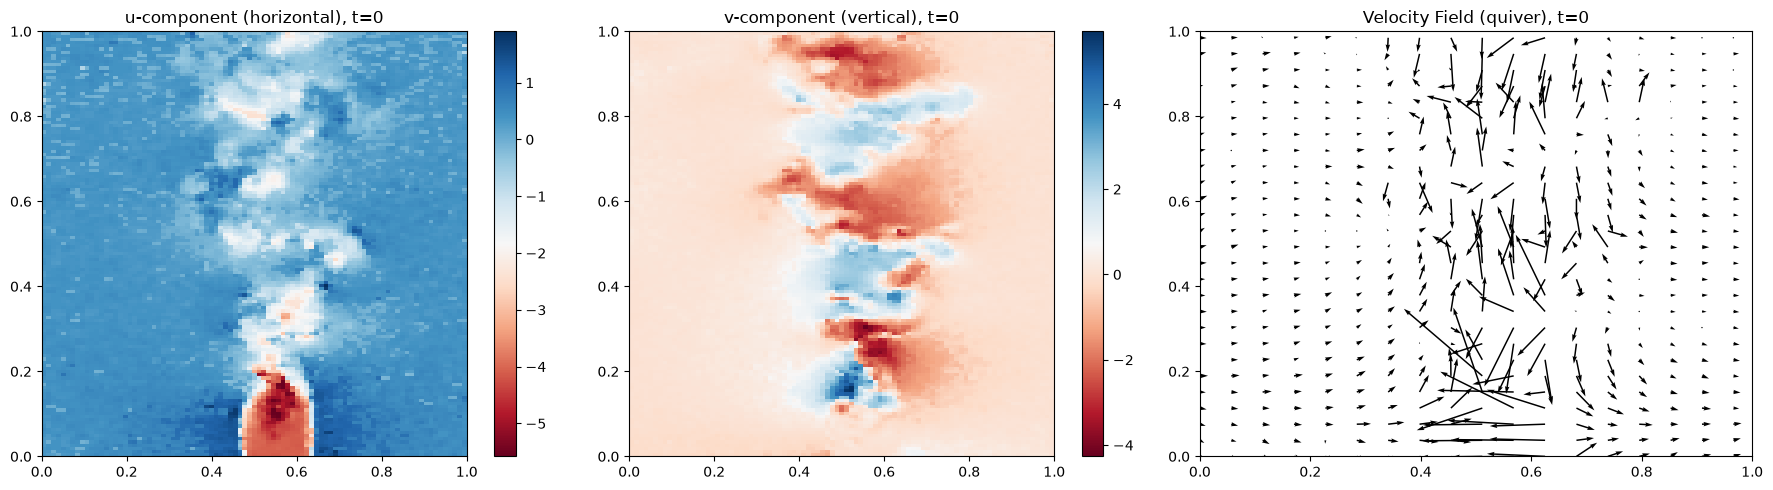

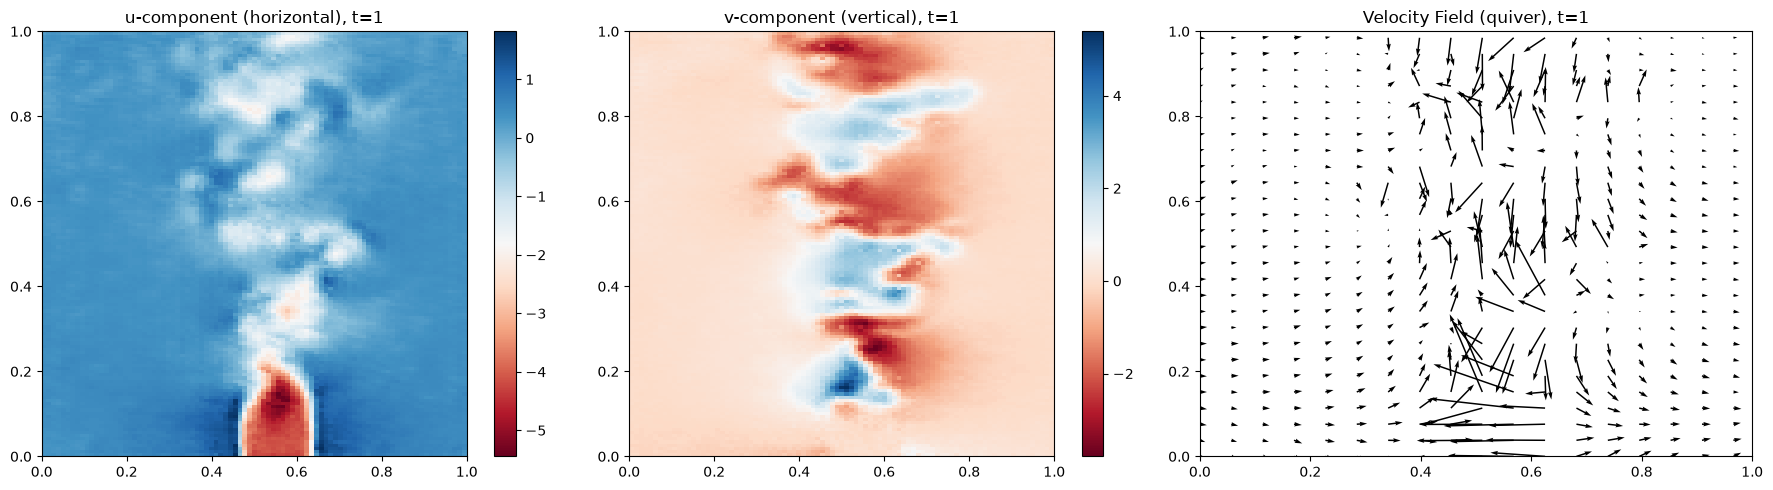

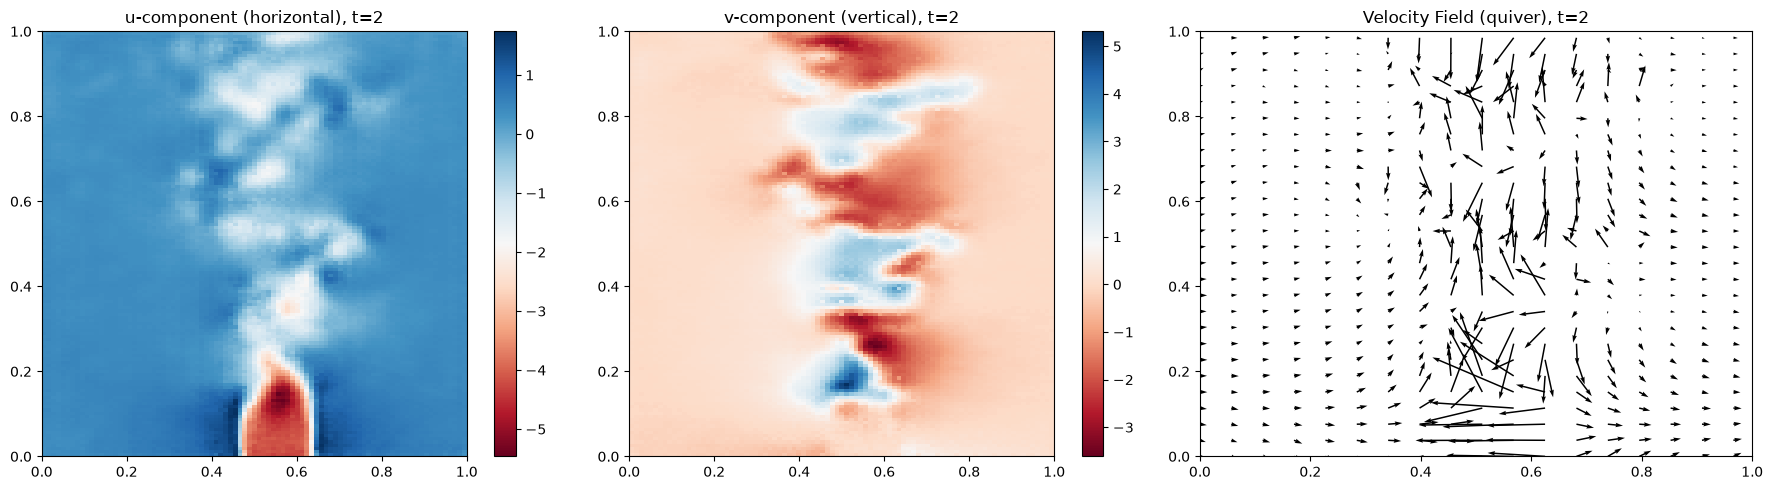

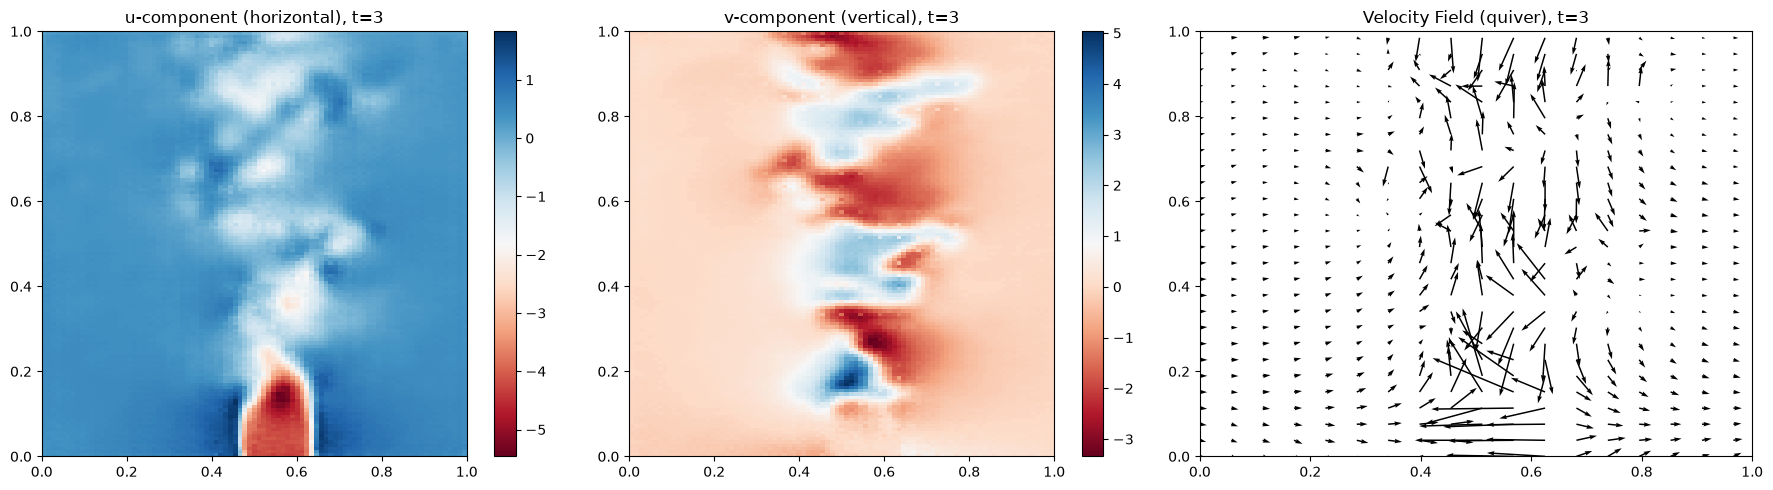

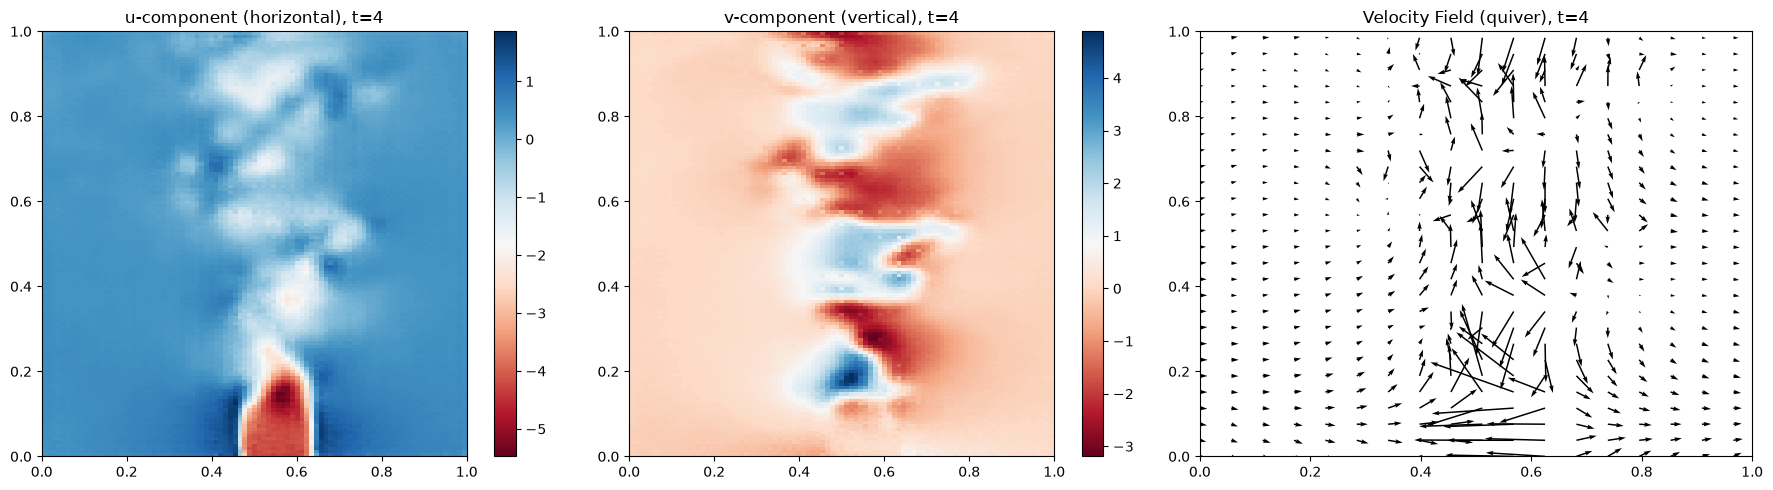

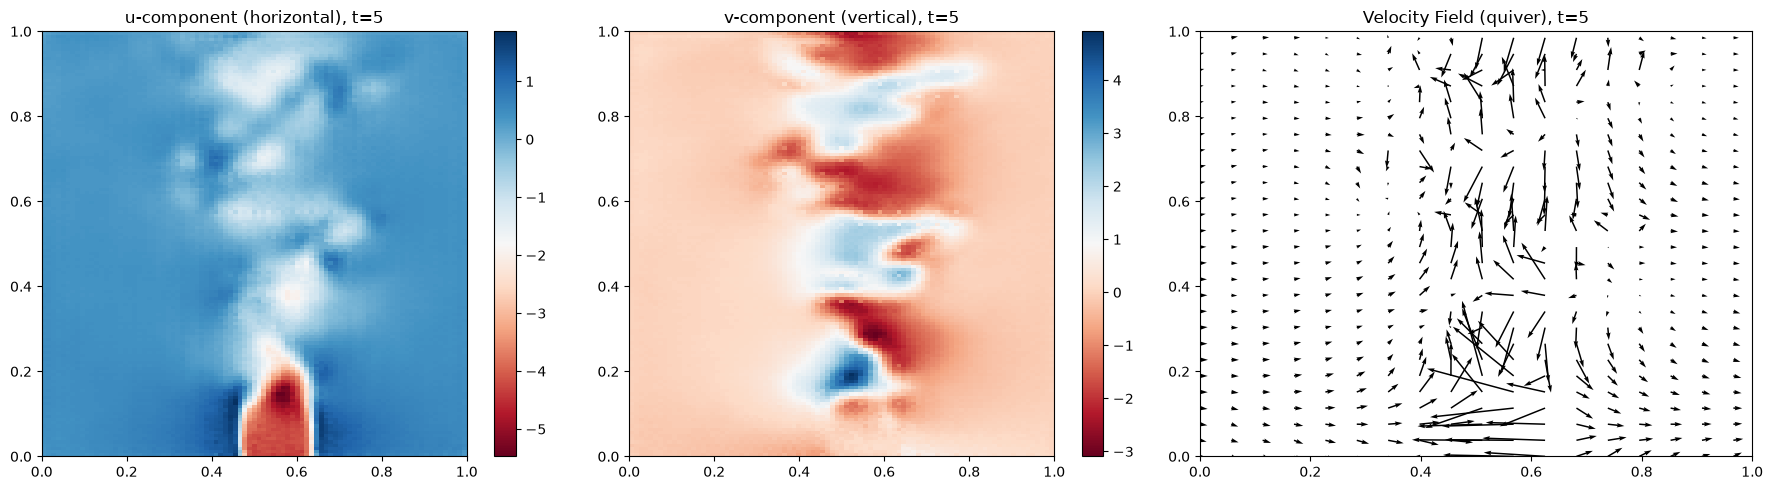

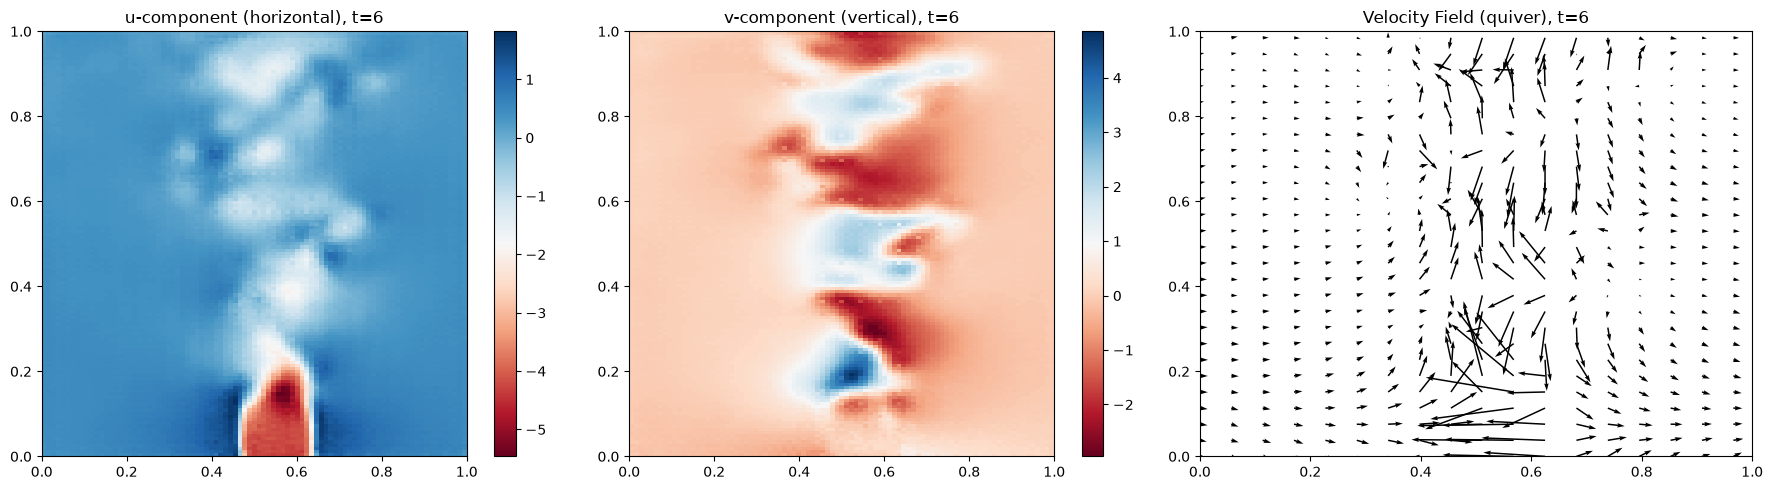

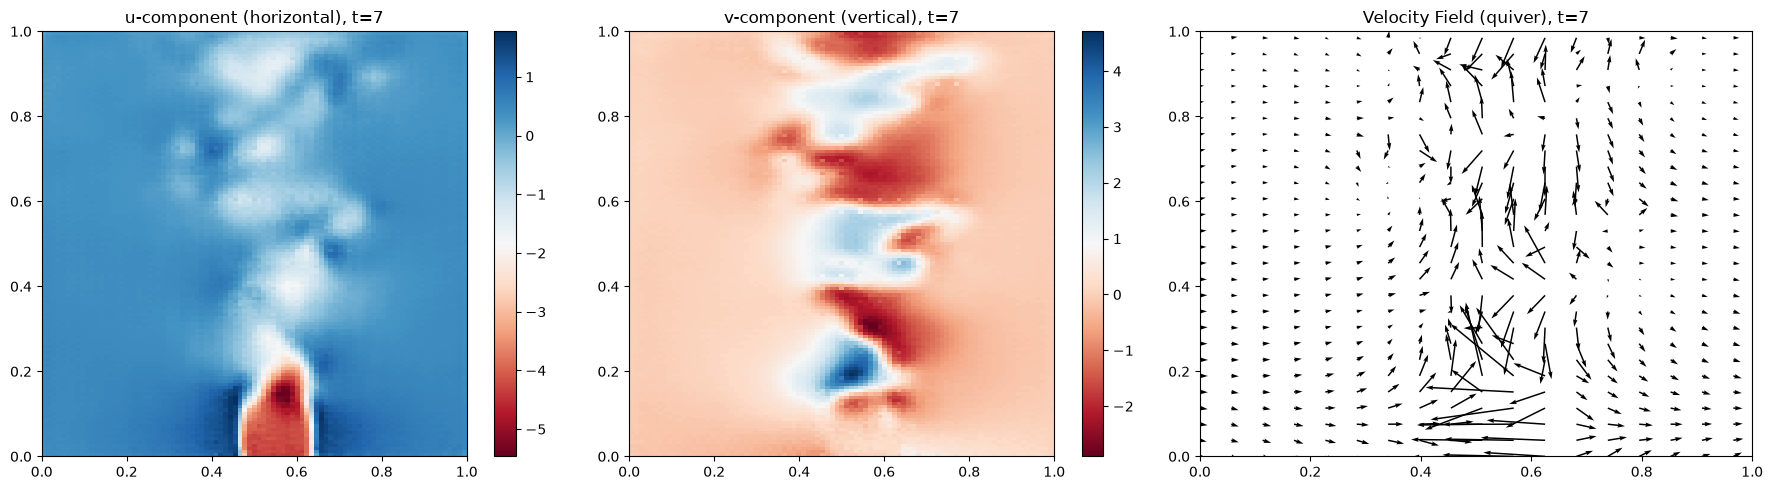

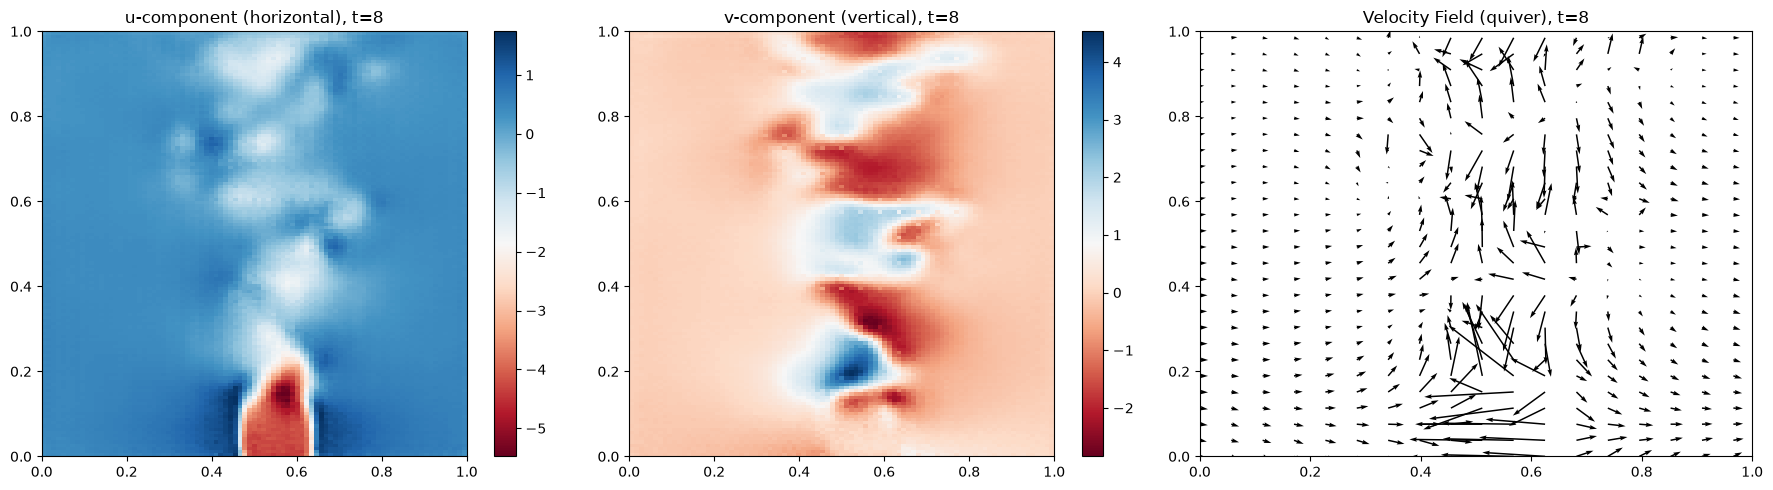

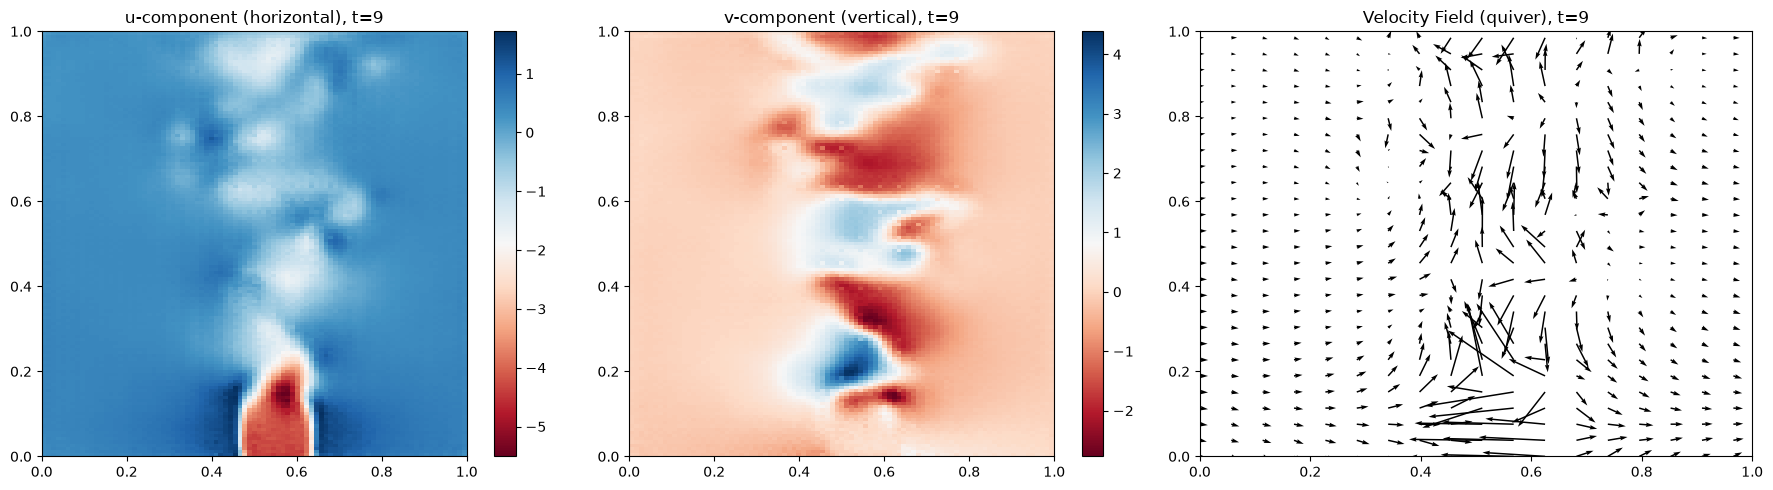

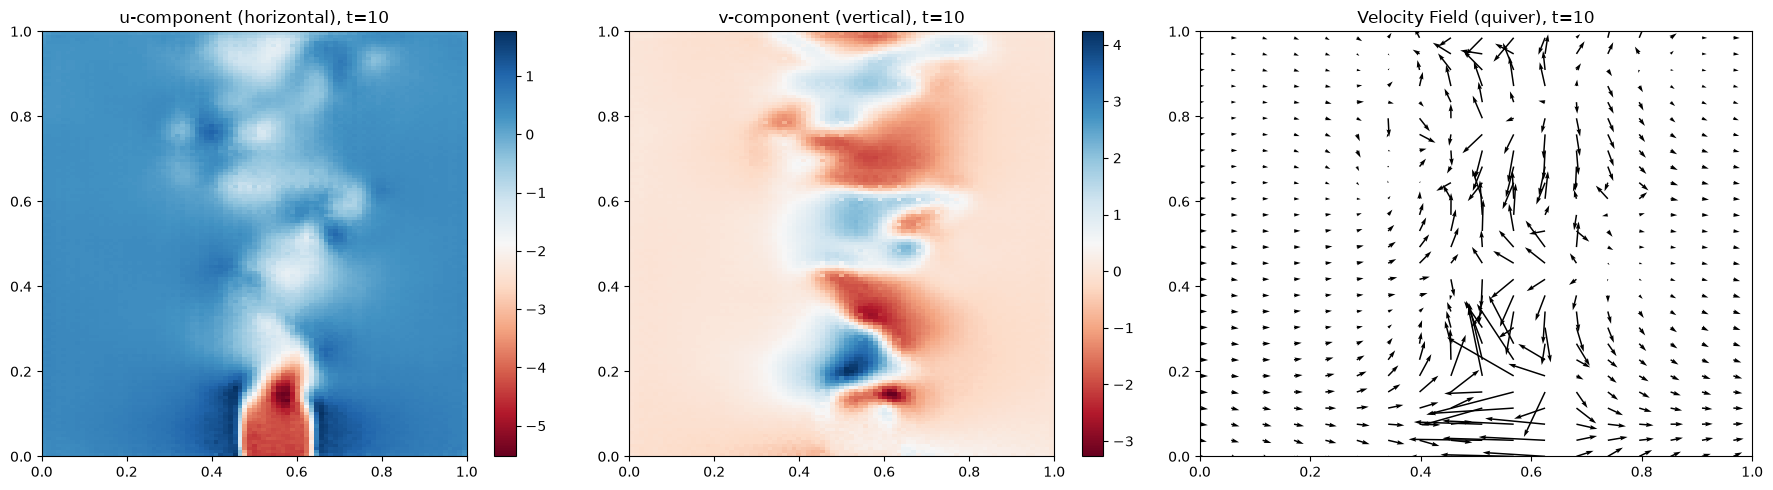

UNet+PITA: saved
  outputs/UNet+PITA/20260907-211757_UNet+PITA_200epoch_bs16_5Hz_200fps_BASELINE_WITH_PITA.h5
  outputs/UNet+PITA/20260907-211757_UNet+PITA_200epoch_bs16_5Hz_200fps_BASELINE_WITH_PITA.pt


In [23]:
# save PITA
p_h5, p_pt, p_u_actual, p_u_pred = save_run(
    model_pita, 'UNet+PITA', p_train_losses, p_test_losses, pita_tags)


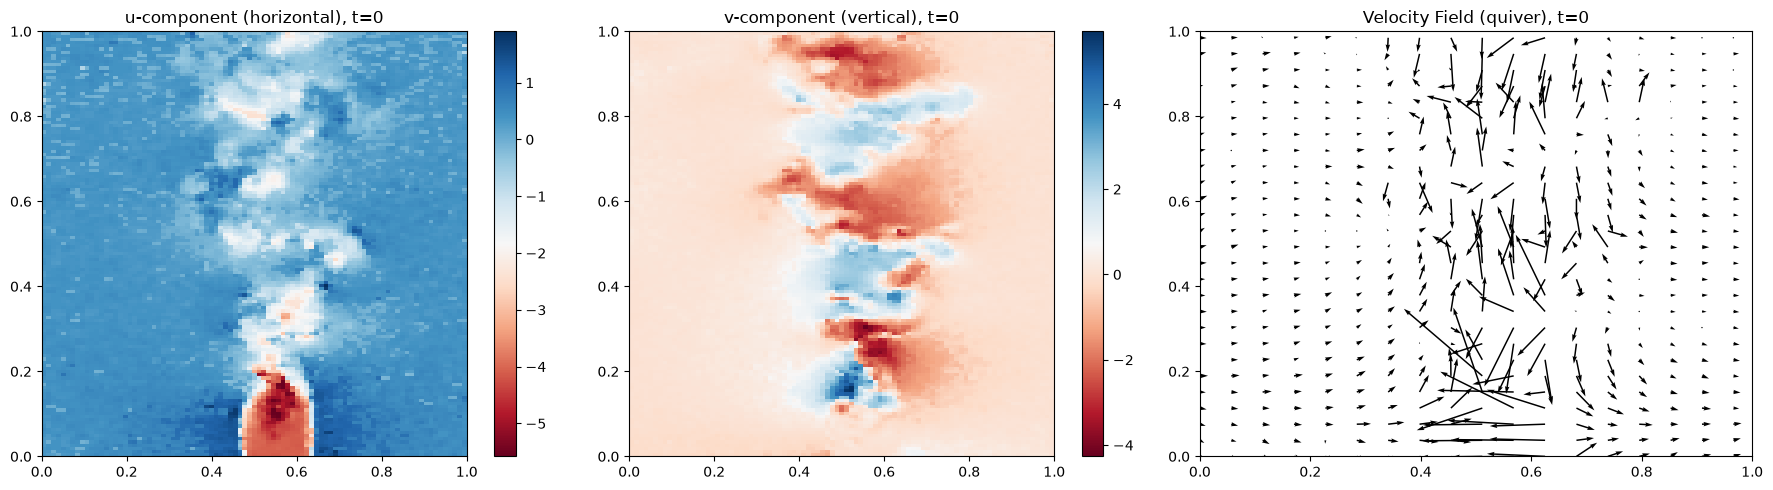

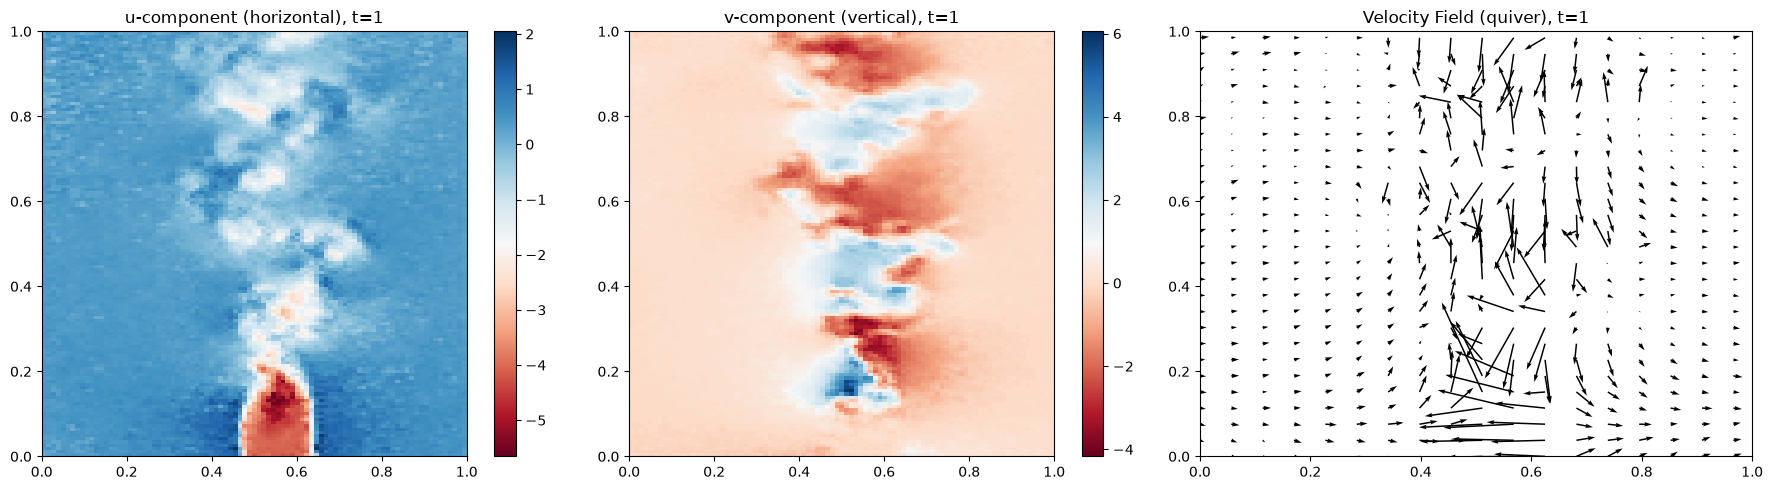

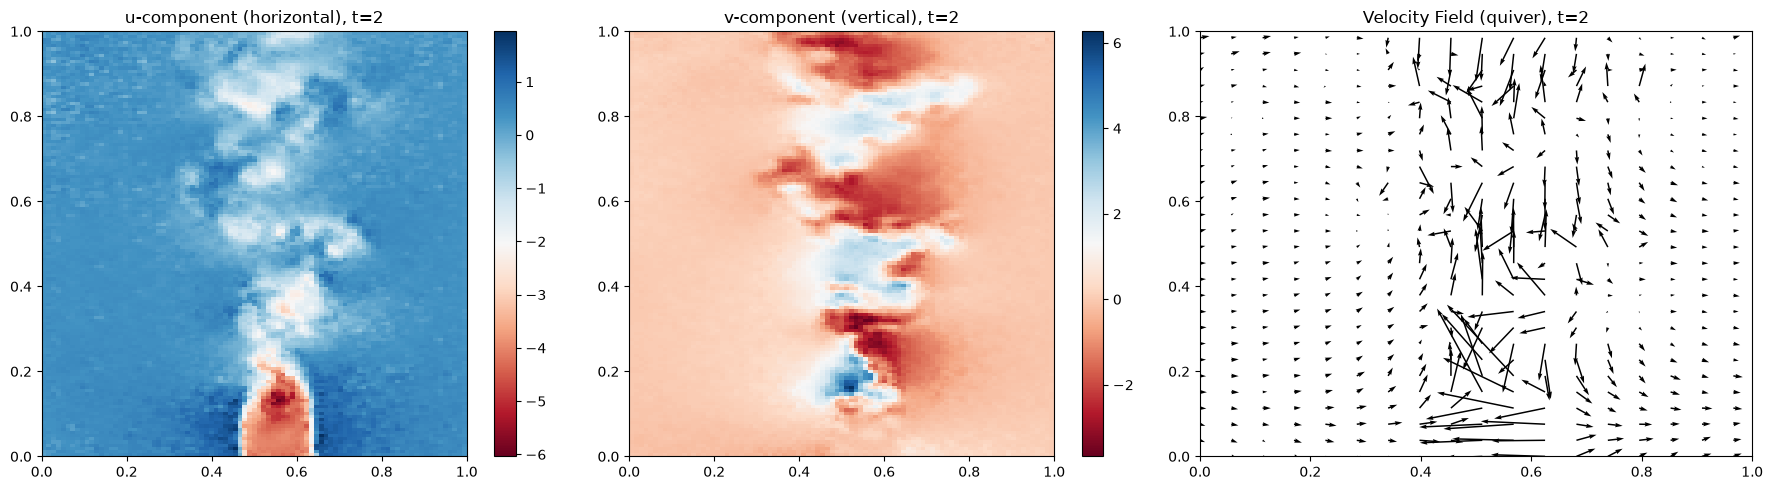

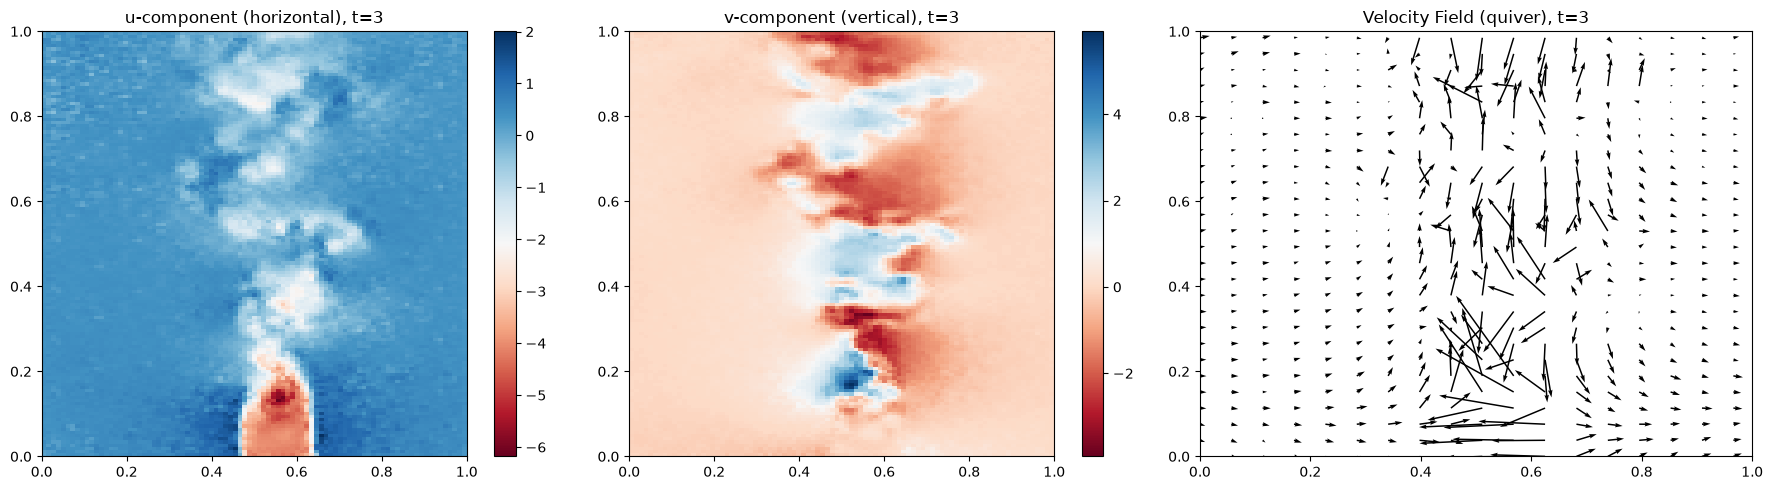

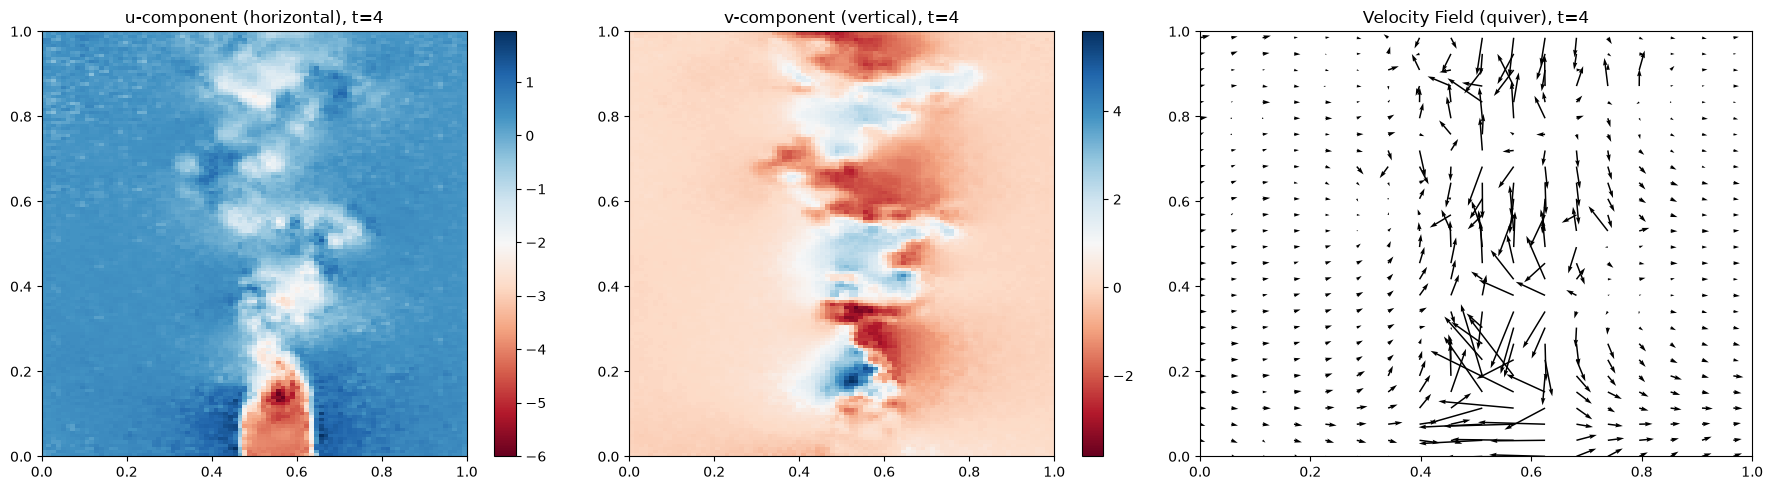

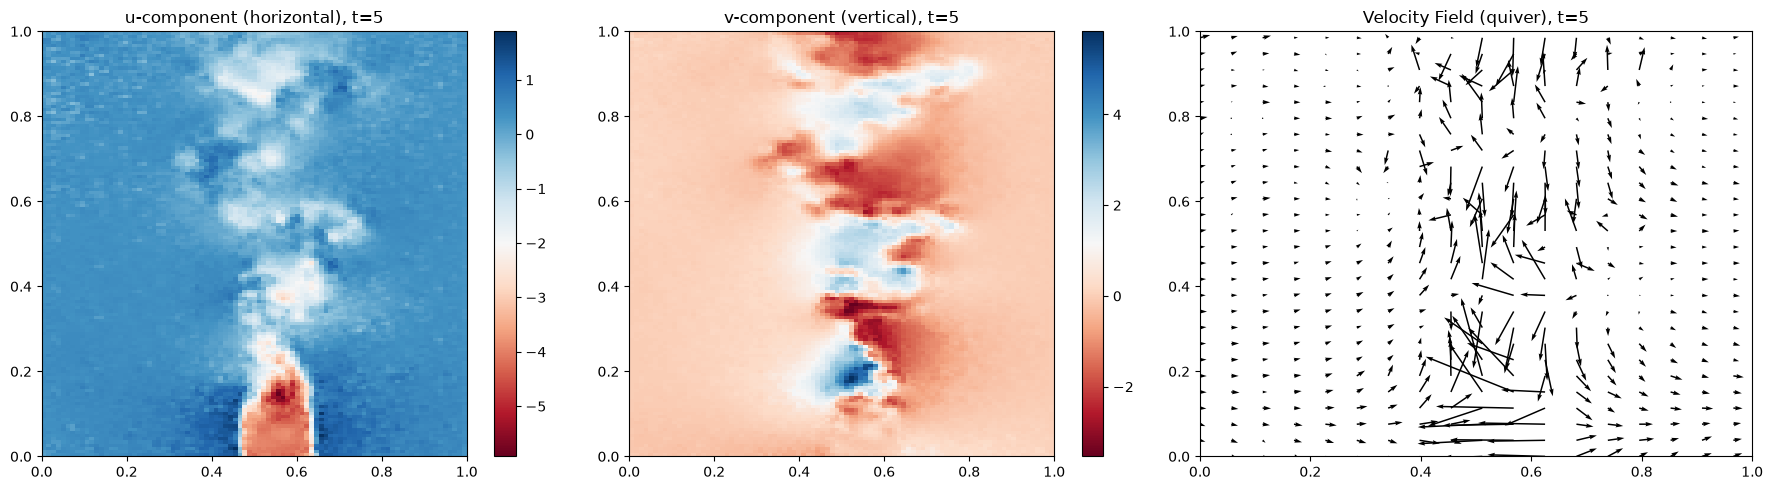

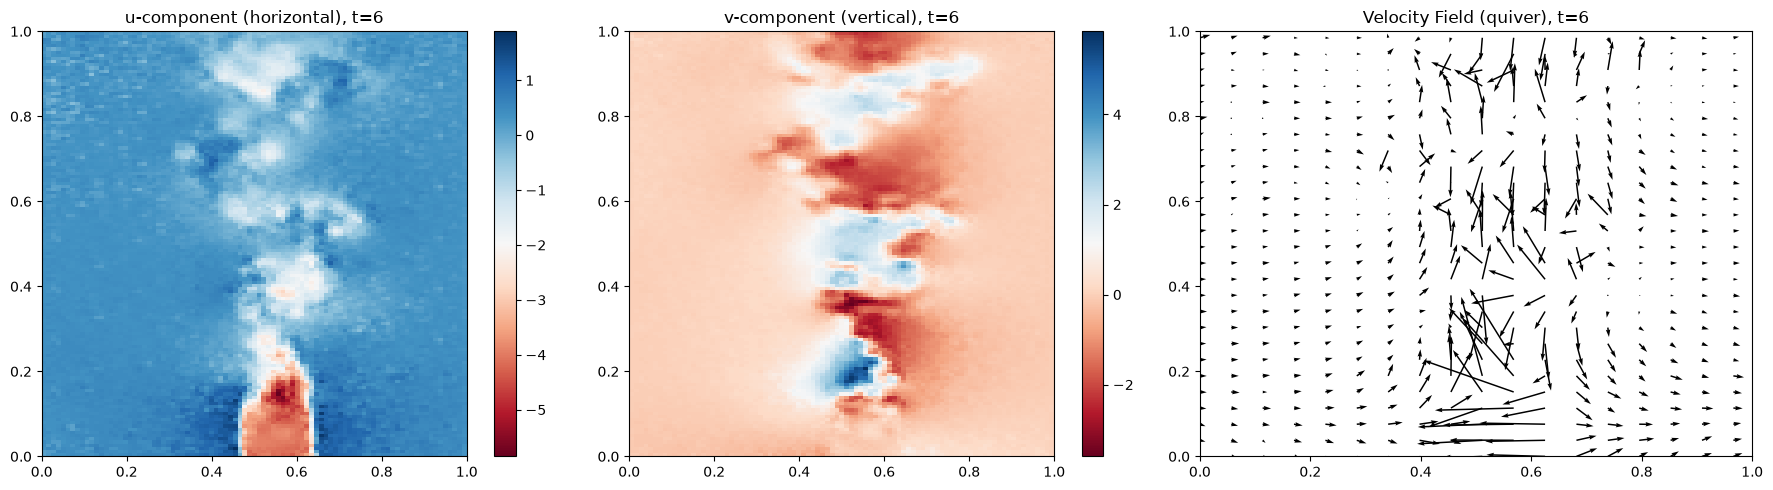

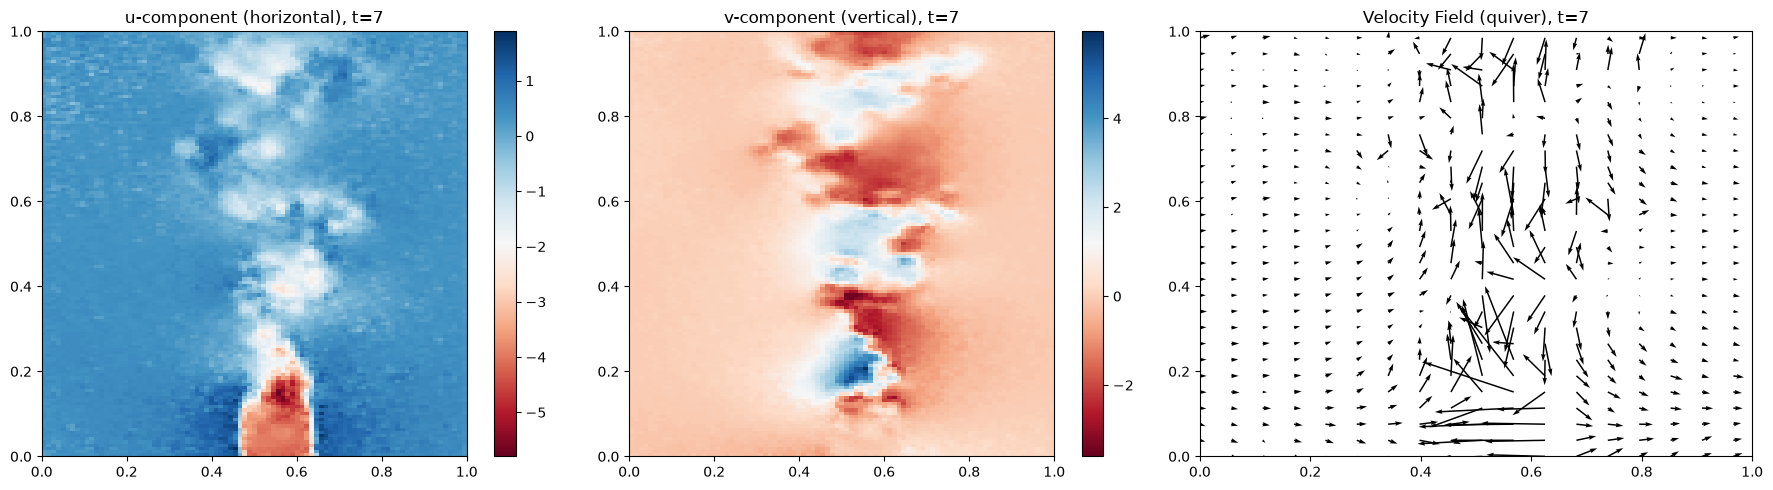

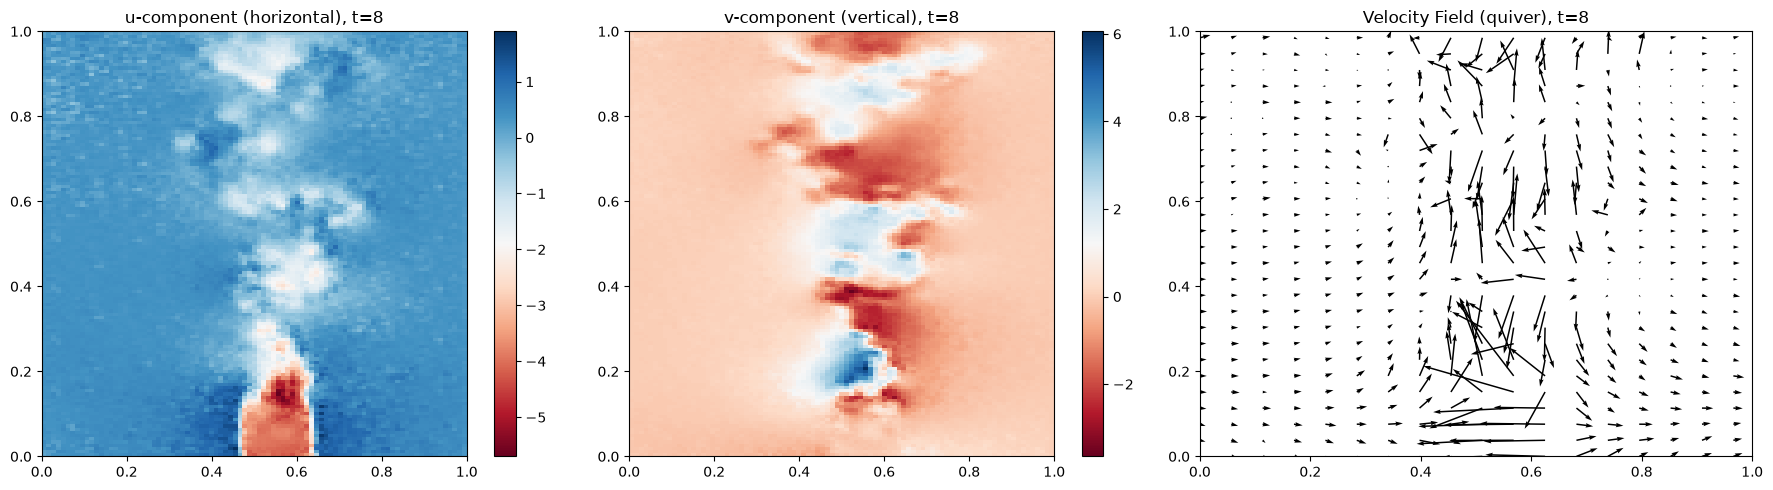

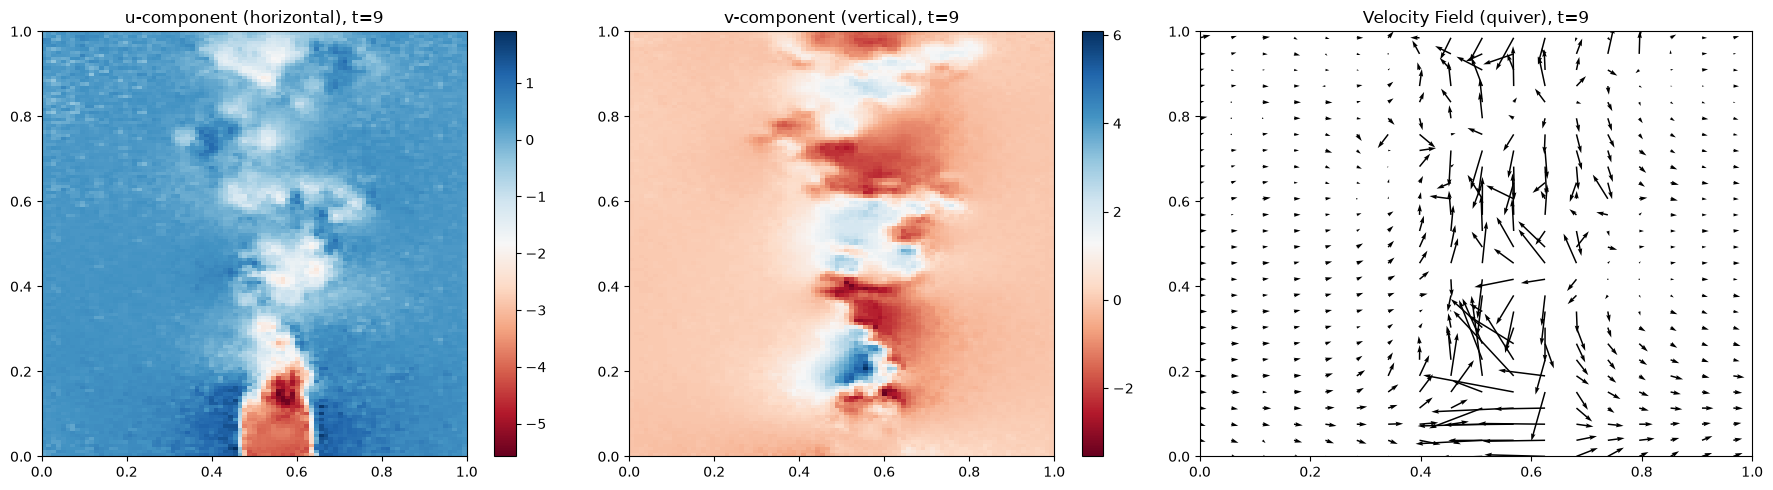

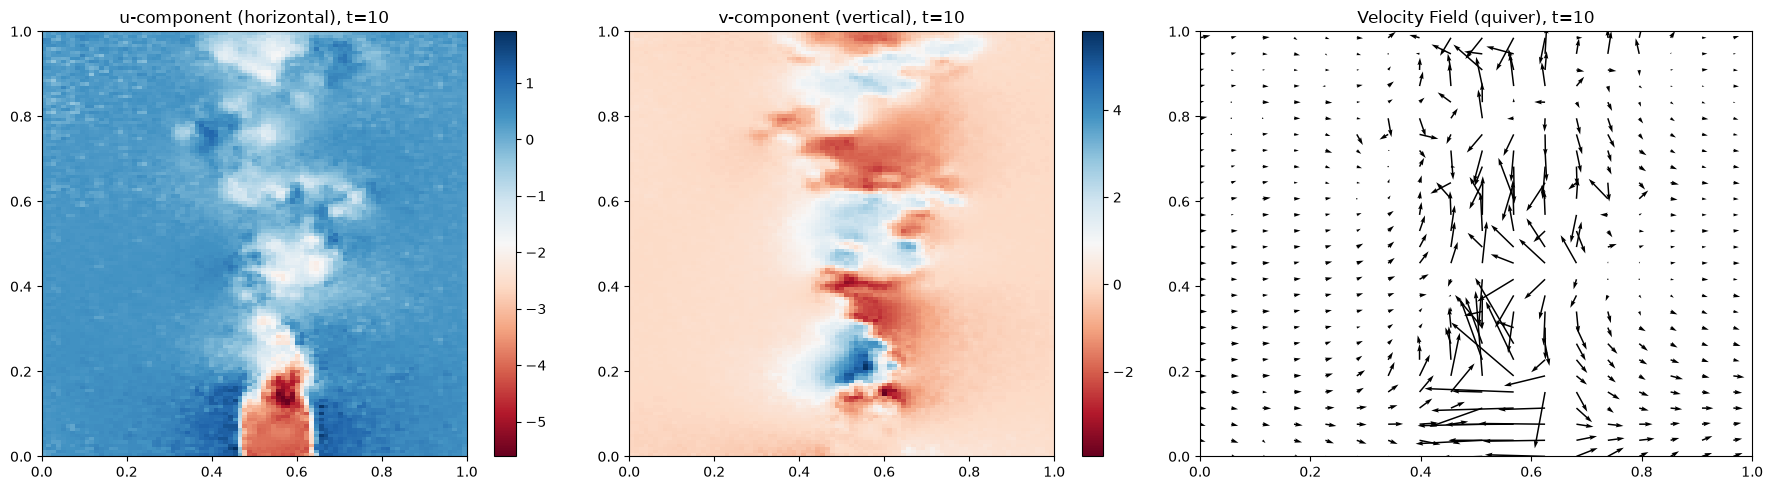

UNet+advNO: saved
  outputs/UNet+advNO/20260907-211805_UNet+advNO_200epoch_bs16_5Hz_200fps_BASELINE_ADV_NO.h5
  outputs/UNet+advNO/20260907-211805_UNet+advNO_200epoch_bs16_5Hz_200fps_BASELINE_ADV_NO.pt


In [24]:
# save adv-NO
a_h5, a_pt, a_u_actual, a_u_pred = save_run(
    model_adv, 'UNet+advNO', a_train_losses, a_test_losses, adv_tags)


In [ ]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Select a specific time step for the snapshot
time_step = 5 # You can change this to any desired time step within the data range

# Get the instantaneous velocity fields at the selected time step
u_x_snapshot = u_x[0, :, :, time_step].cpu().numpy()
u_y_snapshot = u_y[0, :, :, time_step].cpu().numpy()

# Visualize the instantaneous fields
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Plot u_x_snapshot
im0 = axes[0].imshow(u_x_snapshot, origin="lower", cmap="RdBu")
axes[0].set_title(f"Instantaneous u_x (Horizontal Velocity) at time step {time_step}")
divider0 = make_axes_locatable(axes[0])
cax0 = divider0.append_axes("right", size="5%", pad=0.05)
fig.colorbar(im0, cax=cax0)

# Plot u_y_snapshot
im1 = axes[1].imshow(u_y_snapshot, origin="lower", cmap="RdBu")
axes[1].set_title(f"Instantaneous u_y (Vertical Velocity) at time step {time_step}")
divider1 = make_axes_locatable(axes[1])
cax1 = divider1.append_axes("right", size="5%", pad=0.05)
fig.colorbar(im1, cax=cax1)

plt.tight_layout()
plt.show()

In [ ]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Calculate time-averaged velocity fields
u_x_avg = torch.mean(u_x, dim=(0, -1)).cpu().numpy()
u_y_avg = torch.mean(u_y, dim=(0, -1)).cpu().numpy()

# Visualize the time-averaged fields
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Plot u_x_avg
im0 = axes[0].imshow(u_x_avg, origin="lower", cmap="RdBu")
axes[0].set_title("Time-Averaged u_x (Horizontal Velocity)")
divider0 = make_axes_locatable(axes[0])
cax0 = divider0.append_axes("right", size="5%", pad=0.05)
fig.colorbar(im0, cax=cax0)

# Plot u_y_avg
im1 = axes[1].imshow(u_y_avg, origin="lower", cmap="RdBu")
axes[1].set_title("Time-Averaged u_y (Vertical Velocity)")
divider1 = make_axes_locatable(axes[1])
cax1 = divider1.append_axes("right", size="5%", pad=0.05)
fig.colorbar(im1, cax=cax1)

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt

# MSE per timestep for each model
for label, act, pred in [("UNet", b_u_actual, b_u_pred),
                         ("UNet+PITA", p_u_actual, p_u_pred),
                         ("UNet+advNO", a_u_actual, a_u_pred)]:
    u_diff = torch.mean((pred - act) ** 2, dim=(0, 1, 2, 3)).cpu().numpy()
    plt.plot(u_diff, marker="o", label=label)

plt.ylabel("MSE")
plt.xlabel("Timestep")
plt.yscale("log")
plt.title(f"Error of each model at each timestep - {speed}")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.show()
